In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    #library(Seurat)
    #library(M3C)
    #library(batchelor)
})

In [3]:
# chimaera
mixl_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/mlnt/3_QC/raw_counts.rds"
mixl_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/genes.tsv"
mixl_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/mlnt/5_doubletDetection/meta.tab" # contains QC performed by Mlnt

# atlas
atlas_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/raw_counts.mtx"
atlas_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/genes.tsv"
atlas_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/meta.tab"

# refined subclusters Carolina

paraxialmes_meta <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/paraxialmeso_e85_annotation.txt", header = TRUE)
somiticmes_meta  <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/somiticmeso_e85_annotation.txt", header = TRUE)
#bind both together
meta_meso <- rbind(somiticmes_meta, paraxialmes_meta)

# out folder
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/data/"
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"

In [ ]:
meta_meso

# load mixl data
mixl_counts = readRDS(mixl_data_in)
mixl_genes = read.table(mixl_genes_in, stringsAsFactors = F)
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mixl_meta$cell <- paste0('chim_', mixl_meta$cell)
# annotate mixl counts
rownames(mixl_counts) = mixl_genes[,1] #ensembl
colnames(mixl_counts) = mixl_meta$cell

# load atlas data
atlas_counts = readMM(atlas_data_in) # readMM for .mtx input 
atlas_genes = read.table(atlas_genes_in, stringsAsFactors = F)
atlas_meta = read.table(atlas_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)
# annotate atlas counts
rownames(atlas_counts) = atlas_genes[,1] #ensembl
colnames(atlas_counts) = atlas_meta$cell



In [ ]:
meta_meso$cell <- paste0('atlas_', meta_meso$cell)
meta_meso

In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
big_meta

In [ ]:
colnames(big_meta)

In [ ]:
#big_meta.obs
meta_meso['cell']

In [ ]:
print(unique(big_meta$celltype))
print(unique(meta_meso$celltype))

In [ ]:
length(unique(big_meta$celltype))

In [ ]:
length(unique(meta_meso$celltype))

In [ ]:
unique(meta_meso$celltype)

In [ ]:
dim(big_meta)

In [ ]:
#big_meta_meso = merge(big_meta, meta_meso, by='cell', all.x = TRUE) 
#big_meta_meso

In [ ]:
#colnames(big_meta_meso)
#length(unique(big_meta_meso$celltype.x))
#length(unique(big_meta_meso$celltype.y))
#print(dim(big_meta_meso))
#print(unique(big_meta_meso$celltype.y))

In [ ]:
big_meta$celltype[match(meta_meso$cell, big_meta$cell)] <- levels(meta_meso$celltype)

In [ ]:
colnames(big_meta)
length(unique(big_meta$celltype))
print(dim(big_meta))
print(unique(big_meta$celltype))

In [ ]:
big_meta

In [ ]:
#Save big_meta to new file for the rest as big_meta meso > or was it not necessary to do it now?

# Remapping of paraxial and somitic mesoderm chimeric cells to refined subclusters

In [153]:
# Load in data
big_meta = read.table(paste0(out_folder,"big_meta_mapping+meso3.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
pca_after = as.data.frame(read.csv(paste0(out_folder, 'corrected_pc_complete.csv'), header=T, row.names=1,sep=","))
pca_after$cell <- rownames(pca_after)

In [154]:
# label origin in metadata
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1) 

In [155]:
# split atlas and chimaera
atlas_cells = big_meta %>% filter(origin=='atlas') %>% .$cell
correct_atlas = pca_after %>% filter(cell %in% atlas_cells)
atlas_meta = big_meta %>% filter(origin=='atlas')
correct_map = pca_after %>% filter(!cell %in% atlas_cells) %>% select(1:50) # keep only PC columns
map_meta = big_meta %>% filter(origin!='atlas') 

In [156]:
# Downsample atlas to 10k cells per timepoint 
keep = lapply(unique(atlas_meta$stage), function(x){
  if(x == "mixed_gastrulation"){
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else if(sum(atlas_meta$stage == x) < 10000) {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
    return(sample(hits, 10000))
  }
})
keep = do.call(c, keep)
keep <- as.list(keep)

atlas_meta = atlas_meta %>% filter(cell %in% keep)
correct_atlas = correct_atlas %>% filter(cell %in% keep) %>% select(1:50)

In [ ]:
## standard mapping only on stage & celltype, add extra columns if you want to map them, e.g. meso_subclust
# indicated by ## ADD HERE

In [159]:
## Code for mapping:

library(BiocNeighbors)

getmode <- function(v, dist) {
  tab = table(v)
  #if tie, break to shortest distance
  if(sum(tab == max(tab)) > 1){
    tied = names(tab)[tab == max(tab)]
    sub = dist[v %in% tied]
    names(sub) = v[v %in% tied]
    return(names(sub)[which.min(sub)])
  } else {
    return(names(tab)[which.max(tab)])
  }
}

mnnMap = function(atlas_pca, atlas_meta, map_pca, map_meta, k_map = 10){ 
  require(BiocNeighbors)
  require(scran)
  
  knns = BiocNeighbors::queryKNN(correct_atlas, correct_map, k = k_map, get.index = TRUE, get.distance = FALSE)
  
  #get closest k matching cells
  k.mapped = t(apply(knns$index, 1, function(x) atlas_meta$cell[x]))
  celltypes = t(apply(k.mapped, 1, function(x) atlas_meta$celltype[match(x, atlas_meta$cell)]))
  stages = t(apply(k.mapped, 1, function(x) atlas_meta$stage[match(x, atlas_meta$cell)]))
  meso_subcluster = t(apply(k.mapped, 1, function(x) atlas_meta$meso_subcluster[match(x, atlas_meta$cell)])) #ADD HERE
  celltype.mapped = apply(celltypes, 1, function(x) getmode(x, 1:length(x)))
  stage.mapped = apply(stages, 1, function(x) getmode(x, 1:length(x)))
  meso.mapped = apply(meso_subcluster, 1, function(x) getmode(x, 1:length(x))) ## ADD HERE
  
  out = lapply(1:length(celltype.mapped), function(x){
    list(cells.mapped = k.mapped[x,],
         celltype.mapped = celltype.mapped[x],
         meso.mapped = meso.mapped[x],     ## ADD HERE
         stage.mapped = stage.mapped[x])
  })
  
  names(out) = map_meta$cell

  return(out)
  
}

In [160]:
# Perform mapping:
mapping = mnnMap(correct_atlas, atlas_meta, correct_map, map_meta, k_map = 10)
  
  cn = substr(names(mapping), 5, nchar(names(mapping))) # remove 
  ct = sapply(mapping, function(x) x$celltype.mapped)
  st = sapply(mapping, function(x) x$stage.mapped)
  #hm = sapply(mapping, function(x) x$meso.mapped) ## ADD HERE
  closest = sapply(mapping, function(x) x$cells.mapped[1])
  
  out = data.frame(cell = cn, celltype.mapped = ct, stage.mapped = st, closest.cell = closest) #meso.mapped = hm ## ADD HERE
# save mapped celltypes
write.csv(out, paste0(out_folder, 'chimaera_meso_mapped.csv')) 

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

...

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

ERROR: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 1, 0


In [ ]:
### visualise mapping
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mapping <- read.csv(paste0(out_folder, 'chimaera_meso_mapped.csv'), row.names=1)
mapping$cell <- rownames(mapping)

# add cell mapping to metadata
big_meta$stage.mapped = as.character(mapping$stage.mapped[match(big_meta$cell, mapping$cell)])
big_meta$celltype.mapped = as.character(mapping$celltype.mapped[match(big_meta$cell, mapping$cell)])
big_meta$meso.mapped = as.character(mapping$meso.mapped[match(big_meta$cell, mapping$cell)]) ## ADD HERE
big_meta$closest.cell = as.character(mapping$closest.cell[match(big_meta$cell, mapping$cell)])

# only plot chimaera cells
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

In [ ]:
### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta_mapping+meso.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [ ]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4')
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$stage.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas stage", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])
  

pdf1 = table(meta$stage.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])


pdf2 = table(meta$stage.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$stage.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])

options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [ ]:

pdf(paste0(plot_folder, "chimaera_stage_mapping.pdf"), height=8, width=10)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

In [ ]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$celltype.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas subclusters", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
  
  

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])


pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$celltype.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [ ]:

pdf(paste0(plot_folder, "chimaera_celltype_mapping_meso.pdf"), height=8, width=20)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

# plot projected cell type on UMAP

In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping+meso.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=",")) %>% select(1:3)
big_meta = merge(big_meta, umap, by='cell')
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plot_colours.R")


In [ ]:
umap

In [ ]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)
p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= celltype)) +
    geom_point(alpha=0.5, size = 0.4) +
    geom_point(data=big_meta_85,aes(color=celltype.mapped),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltype") +
    ggtitle('Mapped celltypes at E8.25/E8.5') +
    theme(legend.position = "none") +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

p2 <- ggplot(big_meta_85, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped celltypes at E8.25/E8.5 (atlas in grey)') +     
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

plot_grid(
  p1, p2,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [ ]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_celltype_mapping+meso.png"), height=1000, width=1000)
    grid.arrange(p1, p2)
dev.off()

In [ ]:
meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")
meso_plot <- big_meta %>% filter(celltype %in% meso | celltype.mapped %in% meso)
p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=celltype.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

p2 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=tdTom),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) + 
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))
                        
grid.arrange(p1, p2, nrow=1)

In [ ]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_meso_mapping.png"), height=750, width=500)
    grid.arrange(p1, p2, nrow = 2)
dev.off()

# Other method to try and do the same as not that many cells seem to map to Carolina's subclusters

In [7]:
big_meta = read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/data/big_meta_mapping+haem2.csv", header = TRUE)

In [8]:
paraxialmes_meta <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/paraxialmeso_e85_annotation.txt", header = TRUE)
somiticmes_meta  <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/somiticmeso_e85_annotation.txt", header = TRUE)
#bind both together
meta_meso <- rbind(somiticmes_meta, paraxialmes_meta)

In [9]:
meta_meso$cell <- paste0('atlas_', meta_meso$cell)
meta_meso

cell,louvain_cluster,louvain_colours,celltype,celltype_colours
<chr>,<int>,<chr>,<chr>,<chr>
atlas_cell_36870,2,blue,Presomitic_mesoderm,blue
atlas_cell_36873,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_36883,2,blue,Presomitic_mesoderm,blue
atlas_cell_36915,2,blue,Presomitic_mesoderm,blue
atlas_cell_36995,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_37150,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_37178,2,blue,Presomitic_mesoderm,blue
atlas_cell_37225,2,blue,Presomitic_mesoderm,blue
atlas_cell_37284,2,blue,Presomitic_mesoderm,blue


In [10]:
meso_subcluster = List()
big_meta["meso_subcluster"] <- NA

In [11]:
colnames(big_meta)

[1] "X.1"                  "X"                    "barcode"             
 [4] "batch"                "cell"                 "celltype"            
 [7] "celltype.mapped"      "closest.cell"         "cluster"             
[10] "cluster.stage"        "cluster.sub"          "cluster.theiler"     
[13] "colour"               "doub.density"         "doublet"             
[16] "endo_gephiX"          "endo_gephiY"          "endo_gutCluster"     
[19] "endo_gutDPT"          "endo_gutX"            "endo_gutY"           
[22] "endo_trajectoryDPT"   "endo_trajectoryName"  "haem_gephiX"         
[25] "haem_gephiY"          "haem_subclust"        "sample"              
[28] "sequencing.batch"     "sizeFactor"           "stage"               
[31] "stage.mapped"         "stripped"             "tdTom"               
[34] "theiler"              "umapX"                "umapY"               
[37] "origin"               "haem_subclust.mapped" "celltype_origin"     
[40] "meso_subcluster"

In [12]:
big_meta

X.1,X,barcode,batch,cell,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,⋯,stage.mapped,stripped,tdTom,theiler,umapX,umapY,origin,haem_subclust.mapped,celltype_origin,meso_subcluster
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
1,atlas_cell_1-0,AAAGGCCTCCACAA,0,atlas_cell_1,Epiblast,nan,nan,2,2,⋯,nan,0,nan,TS9,-10.227546,-2.8816875,atlas,NA,NA,NA
2,atlas_cell_2-0,AACAAACTCGCCTT,0,atlas_cell_2,Primitive Streak,nan,nan,12,1,⋯,nan,0,nan,TS9,-6.625458,0.1089605,atlas,NA,NA,NA
3,atlas_cell_5-0,AACAGAGAATCAGC,0,atlas_cell_5,ExE ectoderm,nan,nan,3,4,⋯,nan,0,nan,TS9,10.061009,-0.0293132,atlas,NA,NA,NA
4,atlas_cell_6-0,AACATATGAATCGC,0,atlas_cell_6,Epiblast,nan,nan,1,3,⋯,nan,0,nan,TS9,-10.454418,-0.2694517,atlas,NA,NA,NA
5,atlas_cell_8-0,AACCGATGGCTTCC,0,atlas_cell_8,Epiblast,nan,nan,2,2,⋯,nan,0,nan,TS9,-11.047206,-2.2052687,atlas,NA,NA,NA
6,atlas_cell_9-0,AACGTGTGCTCTAT,0,atlas_cell_9,Epiblast,nan,nan,2,2,⋯,nan,0,nan,TS9,-11.111009,-2.7534415,atlas,NA,NA,NA
7,atlas_cell_10-0,AACTGTCTTCGCAA,0,atlas_cell_10,Epiblast,nan,nan,1,2,⋯,nan,0,nan,TS9,-11.243532,-0.8761099,atlas,NA,NA,NA
8,atlas_cell_11-0,AAGAACGACCAATG,0,atlas_cell_11,Epiblast,nan,nan,2,2,⋯,nan,0,nan,TS9,-11.821900,-2.1643126,atlas,NA,NA,NA
9,atlas_cell_12-0,AAGATGGACATTGG,0,atlas_cell_12,Visceral endoderm,nan,nan,11,5,⋯,nan,0,nan,TS9,-2.112586,-12.8742750,atlas,NA,NA,NA


# trying to subset only chimera cells

In [9]:
# label origin in metadata
#big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1) 

In [13]:
big_meta_chim = big_meta %>% filter(origin=='wt') %>% .$cell

In [14]:
chim_meta = big_meta %>% filter(origin=='wt')
chim_meta

X.1,X,barcode,batch,cell,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,⋯,stage.mapped,stripped,tdTom,theiler,umapX,umapY,origin,haem_subclust.mapped,celltype_origin,meso_subcluster
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
116313,wt_cell_1-1,AAACCTGAGACCTTTG,1,wt_cell_1,Haematoendothelial progenitors,Haematoendothelial progenitors,atlas_cell_52006,NA,NA,⋯,E7.5,0,pos,nan,NA,NA,wt,Haem2,NA,NA
116314,wt_cell_2-1,AAACCTGAGCGCCTCA,1,wt_cell_2,Mesenchyme,Mesenchyme,atlas_cell_33502,NA,NA,⋯,E8.0,0,pos,nan,NA,NA,wt,NA,NA,NA
116315,wt_cell_3-1,AAACCTGAGGATCGCA,1,wt_cell_3,Primitive Streak,Primitive Streak,atlas_cell_112755,NA,NA,⋯,E7.0,0,pos,nan,NA,NA,wt,NA,NA,NA
116316,wt_cell_4-1,AAACCTGCACGTAAGG,1,wt_cell_4,NMP,NMP,atlas_cell_68127,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116317,wt_cell_5-1,AAACCTGCAGACAGGT,1,wt_cell_5,Caudal Mesoderm,Caudal Mesoderm,atlas_cell_68596,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116318,wt_cell_6-1,AAACCTGGTCTAGCCG,1,wt_cell_6,Surface ectoderm,Surface ectoderm,atlas_cell_127534,NA,NA,⋯,E8.0,0,pos,nan,NA,NA,wt,NA,NA,NA
116319,wt_cell_7-1,AAACCTGGTGAGTGAC,1,wt_cell_7,NMP,NMP,atlas_cell_95254,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116320,wt_cell_8-1,AAACGGGCACGTGAGA,1,wt_cell_8,Somitic mesoderm,Somitic mesoderm,atlas_cell_27303,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116321,wt_cell_9-1,AAACGGGGTGAAAGAG,1,wt_cell_9,Haematoendothelial progenitors,Haematoendothelial progenitors,atlas_cell_57816,NA,NA,⋯,mixed_gastrulation,0,pos,nan,NA,NA,wt,Haem1,NA,NA


In [15]:
#filter stages E8.5 and E8.25
chim_meta_85 <- chim_meta %>% filter(chim_meta$stage %in% c('E8.5', 'E8.25'))

In [16]:
chim_meta_85

X.1,X,barcode,batch,cell,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,⋯,stage.mapped,stripped,tdTom,theiler,umapX,umapY,origin,haem_subclust.mapped,celltype_origin,meso_subcluster
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
126263,wt_cell_9951-1,AAACCTGAGACTGTAA,1,wt_cell_9951,Mesenchyme,Mesenchyme,atlas_cell_121165,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
126264,wt_cell_9952-1,AAACCTGAGATGCCTT,1,wt_cell_9952,Endothelium,Endothelium,atlas_cell_96660,NA,NA,⋯,E8.5,0,pos,nan,NA,NA,wt,EC7,NA,NA
126265,wt_cell_9953-1,AAACCTGAGCAGCCTC,1,wt_cell_9953,Allantois,Allantois,atlas_cell_99680,NA,NA,⋯,E8.5,0,pos,nan,NA,NA,wt,NA,NA,NA
126266,wt_cell_9954-1,AAACCTGCATACTCTT,1,wt_cell_9954,Erythroid3,Erythroid3,atlas_cell_135387,NA,NA,⋯,E8.5,0,pos,nan,NA,NA,wt,Ery4,NA,NA
126267,wt_cell_9955-1,AAACGGGTCAACACCA,1,wt_cell_9955,Erythroid1,Erythroid1,atlas_cell_129986,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,Ery1,NA,NA
126268,wt_cell_9956-1,AAACGGGTCACTCTTA,1,wt_cell_9956,Endothelium,Endothelium,atlas_cell_39198,NA,NA,⋯,E8.5,0,pos,nan,NA,NA,wt,EC7,NA,NA
126269,wt_cell_9957-1,AAAGATGAGCTGTCTA,1,wt_cell_9957,Pharyngeal mesoderm,Pharyngeal mesoderm,atlas_cell_67292,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
126270,wt_cell_9958-1,AAAGATGAGGGAAACA,1,wt_cell_9958,Forebrain/Midbrain/Hindbrain,Forebrain/Midbrain/Hindbrain,atlas_cell_68354,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
126271,wt_cell_9959-1,AAAGATGAGTTGAGTA,1,wt_cell_9959,Forebrain/Midbrain/Hindbrain,Forebrain/Midbrain/Hindbrain,atlas_cell_39728,NA,NA,⋯,E8.5,0,pos,nan,NA,NA,wt,NA,NA,NA


In [ ]:
#chim_meta_85$celltype.mapped[match(meta_meso$cell, chim_meta_85$closest.cell)] <- levels(meta_meso$celltype)

In [17]:
#Filter only the cells in chim_meta that also appear in the refined meta_meso
chim_meta_85f <- chim_meta %>% filter(chim_meta$closest.cell %in% meta_meso$cell)

In [18]:
chim_meta_85f

X.1,X,barcode,batch,cell,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,⋯,stage.mapped,stripped,tdTom,theiler,umapX,umapY,origin,haem_subclust.mapped,celltype_origin,meso_subcluster
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
116339,wt_cell_27-1,AAAGCAATCCGCATCT,1,wt_cell_27,Somitic mesoderm,Somitic mesoderm,atlas_cell_101498,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116581,wt_cell_269-1,ACGTCAATCTGAGTGT,1,wt_cell_269,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_41190,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116627,wt_cell_315-1,ACTTTCATCAAACAAG,1,wt_cell_315,Somitic mesoderm,Somitic mesoderm,atlas_cell_99472,NA,NA,⋯,E8.5,0,pos,nan,NA,NA,wt,NA,NA,NA
116638,wt_cell_326-1,AGACGTTCACCTCGGA,1,wt_cell_326,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_41072,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116720,wt_cell_408-1,AGCTTGATCAGTTCGA,1,wt_cell_408,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_97576,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116730,wt_cell_418-1,AGGCCGTAGCCACGCT,1,wt_cell_418,Somitic mesoderm,Somitic mesoderm,atlas_cell_38410,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA
116946,wt_cell_634-1,CAAGTTGCATTCACTT,1,wt_cell_634,Somitic mesoderm,Somitic mesoderm,atlas_cell_139157,NA,NA,⋯,E8.0,0,pos,nan,NA,NA,wt,NA,NA,NA
116974,wt_cell_662-1,CACACTCGTATAATGG,1,wt_cell_662,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_100270,NA,NA,⋯,E8.0,0,pos,nan,NA,NA,wt,NA,NA,NA
116997,wt_cell_685-1,CACATTTGTTAGGGTG,1,wt_cell_685,Somitic mesoderm,Somitic mesoderm,atlas_cell_40986,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,NA


In [19]:
meta_meso$celltype <- na.omit(meta_meso$celltype)

In [20]:
print(unique(levels(meta_meso$celltype)))

NULL


In [21]:
rownames(meta_meso) = unique(meta_meso$cell)

In [22]:
na.omit(meta_meso[chim_meta_85$closest.cell,])

,cell,louvain_cluster,louvain_colours,celltype,celltype_colours
,<chr>,<int>,<chr>,<chr>,<chr>
atlas_cell_98468,atlas_cell_98468,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_130759,atlas_cell_130759,2,blue,Presomitic_mesoderm,blue
atlas_cell_137735,atlas_cell_137735,3,brown,Head_mesoderm,darkgreen
atlas_cell_139074,atlas_cell_139074,3,brown,Posterior-most_somites,turquoise
atlas_cell_132649,atlas_cell_132649,1,turquoise,Dermomyotome,brown
atlas_cell_37158,atlas_cell_37158,1,turquoise,Dermomyotome,brown
atlas_cell_99073,atlas_cell_99073,2,blue,Presomitic_mesoderm,blue
atlas_cell_97214,atlas_cell_97214,3,brown,Head_mesoderm,darkgreen
atlas_cell_38563,atlas_cell_38563,1,turquoise,Presomitic_mesoderm,blue


In [23]:
na.omit(meta_meso[meta_meso$celltype,])

cell,louvain_cluster,louvain_colours,celltype,celltype_colours
<chr>,<int>,<chr>,<chr>,<chr>


In [24]:
chim_meta_85f$meso_subcluster <- na.omit(meta_meso[chim_meta_85f$closest.cell,])$celltype

In [25]:
chim_meta_85f

X.1,X,barcode,batch,cell,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,⋯,stage.mapped,stripped,tdTom,theiler,umapX,umapY,origin,haem_subclust.mapped,celltype_origin,meso_subcluster
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
116339,wt_cell_27-1,AAAGCAATCCGCATCT,1,wt_cell_27,Somitic mesoderm,Somitic mesoderm,atlas_cell_101498,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,Posterior-most_somites
116581,wt_cell_269-1,ACGTCAATCTGAGTGT,1,wt_cell_269,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_41190,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,Dermomyotome
116627,wt_cell_315-1,ACTTTCATCAAACAAG,1,wt_cell_315,Somitic mesoderm,Somitic mesoderm,atlas_cell_99472,NA,NA,⋯,E8.5,0,pos,nan,NA,NA,wt,NA,NA,Presomitic_mesoderm
116638,wt_cell_326-1,AGACGTTCACCTCGGA,1,wt_cell_326,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_41072,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,Sclerotome
116720,wt_cell_408-1,AGCTTGATCAGTTCGA,1,wt_cell_408,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_97576,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,Head_mesoderm
116730,wt_cell_418-1,AGGCCGTAGCCACGCT,1,wt_cell_418,Somitic mesoderm,Somitic mesoderm,atlas_cell_38410,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,Posterior-most_somites
116946,wt_cell_634-1,CAAGTTGCATTCACTT,1,wt_cell_634,Somitic mesoderm,Somitic mesoderm,atlas_cell_139157,NA,NA,⋯,E8.0,0,pos,nan,NA,NA,wt,NA,NA,Posterior-most_somites
116974,wt_cell_662-1,CACACTCGTATAATGG,1,wt_cell_662,Paraxial mesoderm,Paraxial mesoderm,atlas_cell_100270,NA,NA,⋯,E8.0,0,pos,nan,NA,NA,wt,NA,NA,Head_mesoderm
116997,wt_cell_685-1,CACATTTGTTAGGGTG,1,wt_cell_685,Somitic mesoderm,Somitic mesoderm,atlas_cell_40986,NA,NA,⋯,E8.25,0,pos,nan,NA,NA,wt,NA,NA,Posterior-most_somites


In [26]:
print(unique(levels(chim_meta_85f$meso_subcluster)))

NULL


In [27]:
unique(chim_meta_85f$celltype.mapped)

[1] "Somitic mesoderm"      "Paraxial mesoderm"     "Intermediate mesoderm"
[4] "Pharyngeal mesoderm"   "NMP"

In [28]:
colnames(big_meta)

[1] "X.1"                  "X"                    "barcode"             
 [4] "batch"                "cell"                 "celltype"            
 [7] "celltype.mapped"      "closest.cell"         "cluster"             
[10] "cluster.stage"        "cluster.sub"          "cluster.theiler"     
[13] "colour"               "doub.density"         "doublet"             
[16] "endo_gephiX"          "endo_gephiY"          "endo_gutCluster"     
[19] "endo_gutDPT"          "endo_gutX"            "endo_gutY"           
[22] "endo_trajectoryDPT"   "endo_trajectoryName"  "haem_gephiX"         
[25] "haem_gephiY"          "haem_subclust"        "sample"              
[28] "sequencing.batch"     "sizeFactor"           "stage"               
[31] "stage.mapped"         "stripped"             "tdTom"               
[34] "theiler"              "umapX"                "umapY"               
[37] "origin"               "haem_subclust.mapped" "celltype_origin"     
[40] "meso_subcluster"

# Now re-merge big_meta and chim_meta_85f since newly clustered cells came from variety of initially celltype.mapped which could affect DEG results

In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [29]:
big_meta$meso.mapped = as.character(chim_meta_85f$meso_subcluster[match(big_meta$cell, chim_meta_85f$cell)])

In [34]:
meso_subcluster = List()
big_meta["meso_subcluster"] <- NA

In [30]:
unique(big_meta$celltype.mapped)

[1] "nan"                            "Haematoendothelial progenitors"
 [3] "Mesenchyme"                     "Primitive Streak"              
 [5] "NMP"                            "Caudal Mesoderm"               
 [7] "Surface ectoderm"               "Somitic mesoderm"              
 [9] "Pharyngeal mesoderm"            "Paraxial mesoderm"             
[11] "Forebrain/Midbrain/Hindbrain"   "Rostral neurectoderm"          
[13] "ExE mesoderm"                   "Neural crest"                  
[15] "Nascent mesoderm"               "Gut"                           
[17] "Notochord"                      "Blood progenitors 2"           
[19] "Intermediate mesoderm"          "Mixed mesoderm"                
[21] "Anterior Primitive Streak"      "Caudal epiblast"               
[23] "Epiblast"                       "Def. endoderm"                 
[25] "Allantois"                      "Spinal cord"                   
[27] "Blood progenitors 1"            "Endothelium"                   
[29] "Caudal neurectoderm"            "Erythroid1"                    
[31] "Cardiomyocytes"                 "ExE ectoderm"                  
[33] "ExE endoderm"                   "Visceral endoderm"             
[35] "PGC"                            "Erythroid3"                    
[37] "Erythroid2"                     "Parietal endoderm"

In [31]:
unique(big_meta$meso.mapped)

[1] NA                       "Posterior-most_somites" "Dermomyotome"          
[4] "Presomitic_mesoderm"    "Sclerotome"             "Head_mesoderm"         
[7] "Anterior-most_somites"

In [32]:
length(unique(big_meta$celltype.mapped))

[1] 38

In [35]:
meta_meso

,cell,louvain_cluster,louvain_colours,celltype,celltype_colours
,<chr>,<int>,<chr>,<chr>,<chr>
atlas_cell_36870,atlas_cell_36870,2,blue,Presomitic_mesoderm,blue
atlas_cell_36873,atlas_cell_36873,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_36883,atlas_cell_36883,2,blue,Presomitic_mesoderm,blue
atlas_cell_36915,atlas_cell_36915,2,blue,Presomitic_mesoderm,blue
atlas_cell_36995,atlas_cell_36995,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_37150,atlas_cell_37150,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_37178,atlas_cell_37178,2,blue,Presomitic_mesoderm,blue
atlas_cell_37225,atlas_cell_37225,2,blue,Presomitic_mesoderm,blue
atlas_cell_37284,atlas_cell_37284,2,blue,Presomitic_mesoderm,blue


In [35]:
big_meta$meso_subcluster = as.character(meta_meso$celltype[match(big_meta$cell, meta_meso$cell)])

In [36]:
unique(big_meta$meso_subcluster)

[1] NA                       "Presomitic_mesoderm"    "Head_mesoderm"         
[4] "Dermomyotome"           "Anterior-most_somites"  "Sclerotome"            
[7] "Posterior-most_somites"

In [40]:
### save big meta with mapping
write.table(big_meta, "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/data/big_meta_mapping+haem+meso.tab", row.names = F, col.names = T, quote = F, sep = "\t")

# Visual representation results

In [41]:
# only plot chimaera cells
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

In [42]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4')
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$stage.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas stage", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])
  

pdf1 = table(meta$stage.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])


pdf2 = table(meta$stage.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$stage.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])

options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

ERROR: Error: Insufficient values in manual scale. 3 needed but only 2 provided.


In [ ]:
pdf(paste0(plot_folder, "chimaera_stage_mapping2.pdf"), height=8, width=10)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

In [48]:
unique(meta$tdTom)

[1] "nan" "pos" "neg"

Warning message:
“Removed 6 rows containing missing values (geom_bar).”


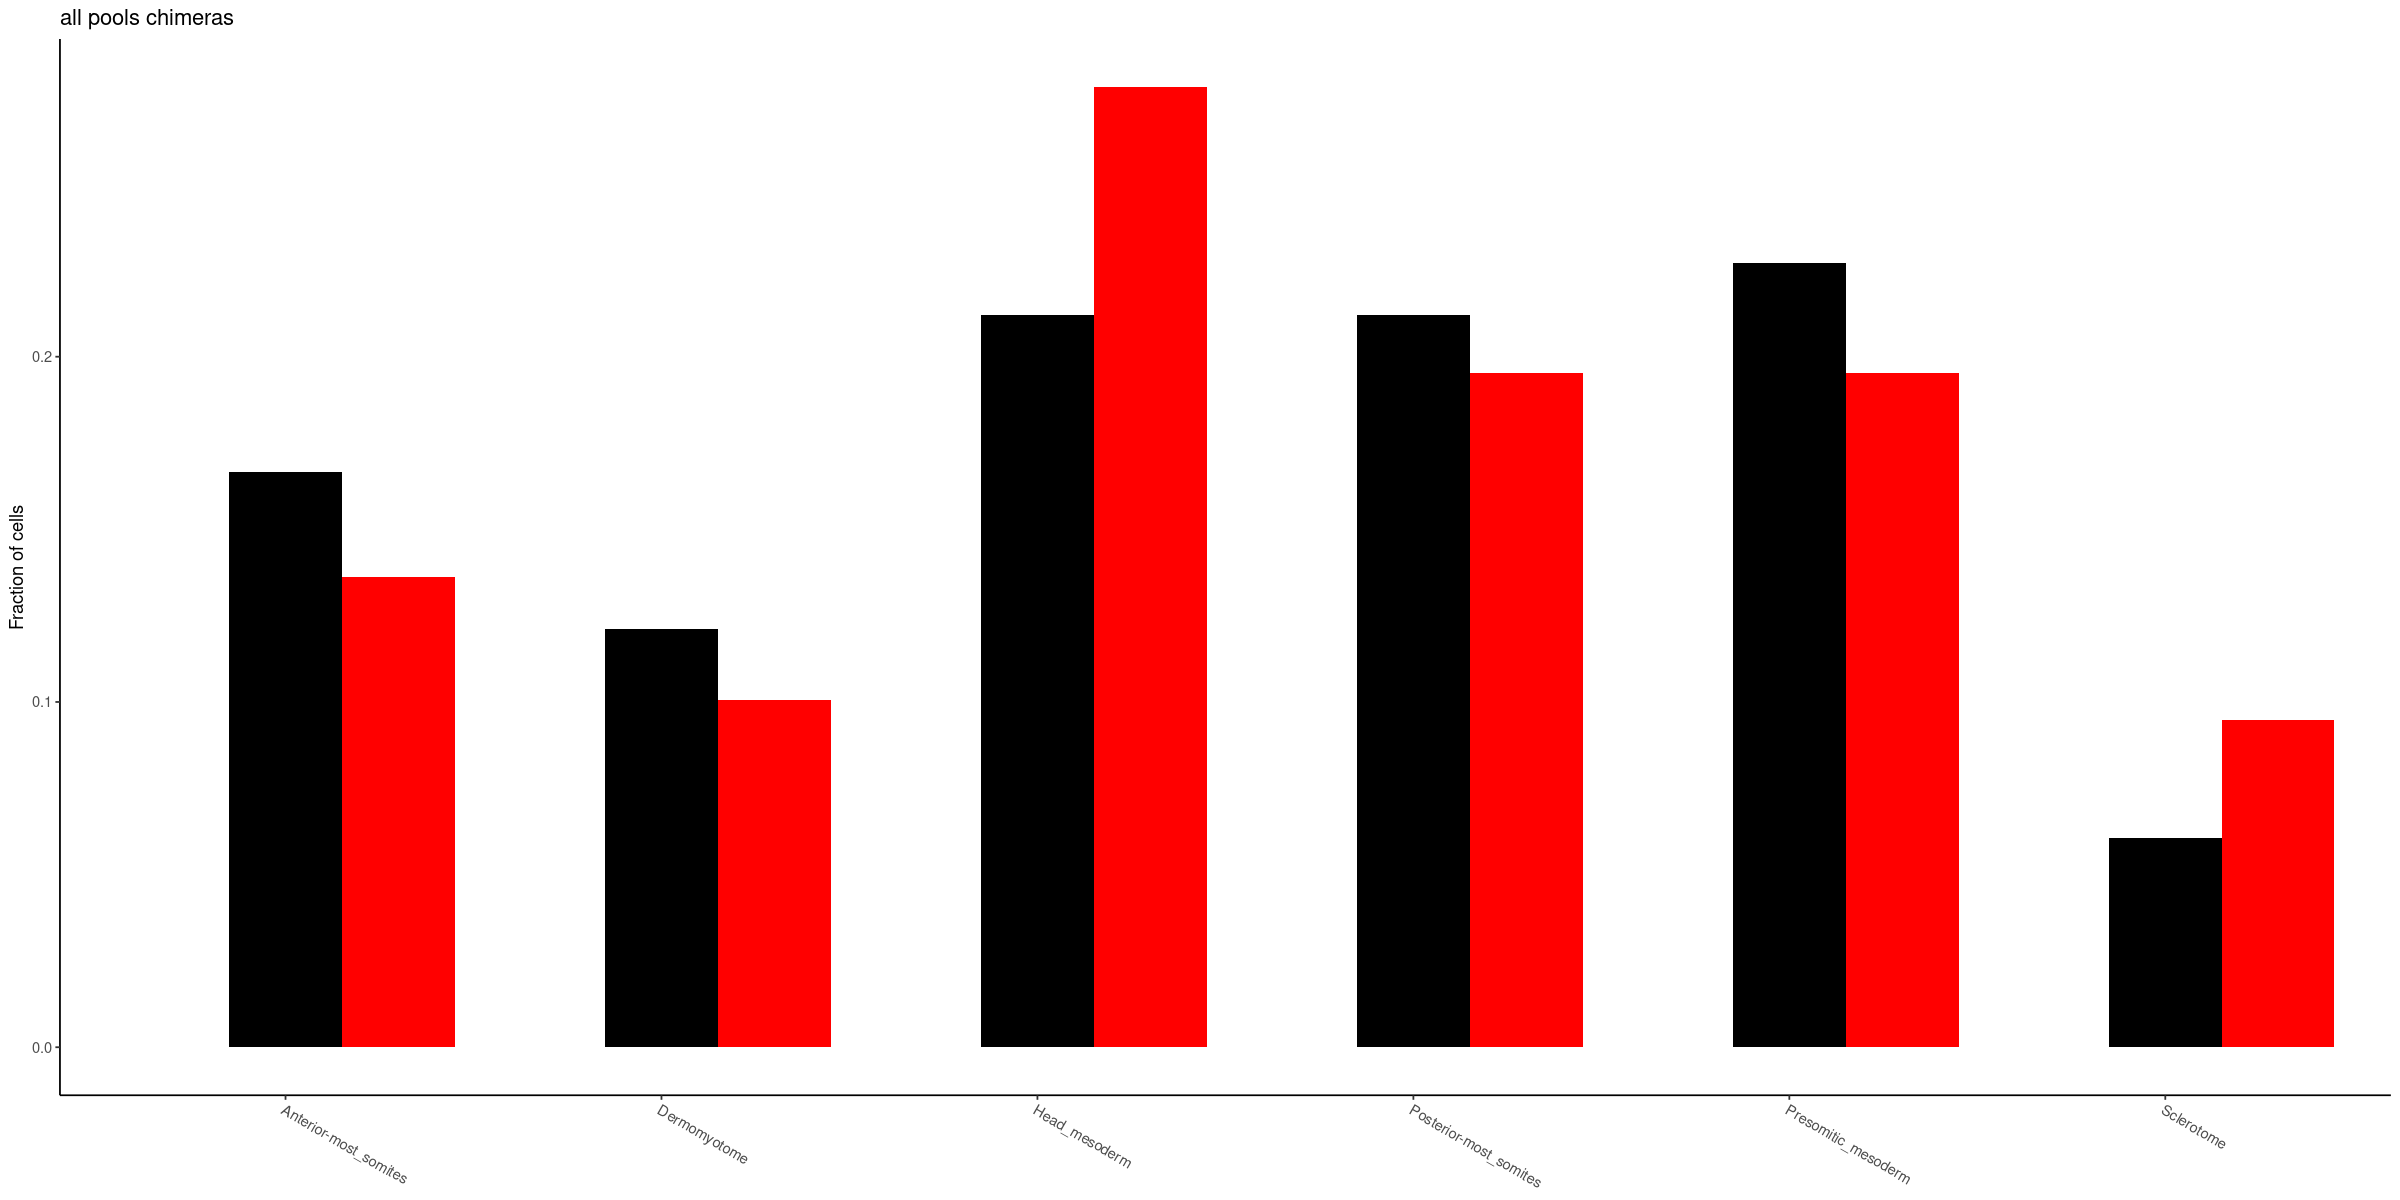

In [49]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$meso.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas subclusters", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])
  
  

pdf1 = table(meta$meso.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])


pdf2 = table(meta$meso.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$meso.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black", "nan" = "white" ), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
plot_grid(p4)

In [50]:

pdf(paste0(plot_folder, "wt_chimaera_celltype_mapping_meso2.pdf"), height=8, width=20)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

Warning message:
“Removed 6 rows containing missing values (geom_bar).”


png 
  2

In [51]:
#big_meta = read.table(paste0(out_folder,"big_meta_mapping+meso2.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
#umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=",")) %>% select(1:3)
#big_meta = merge(big_meta, umap, by='cell')
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plot_colours.R")


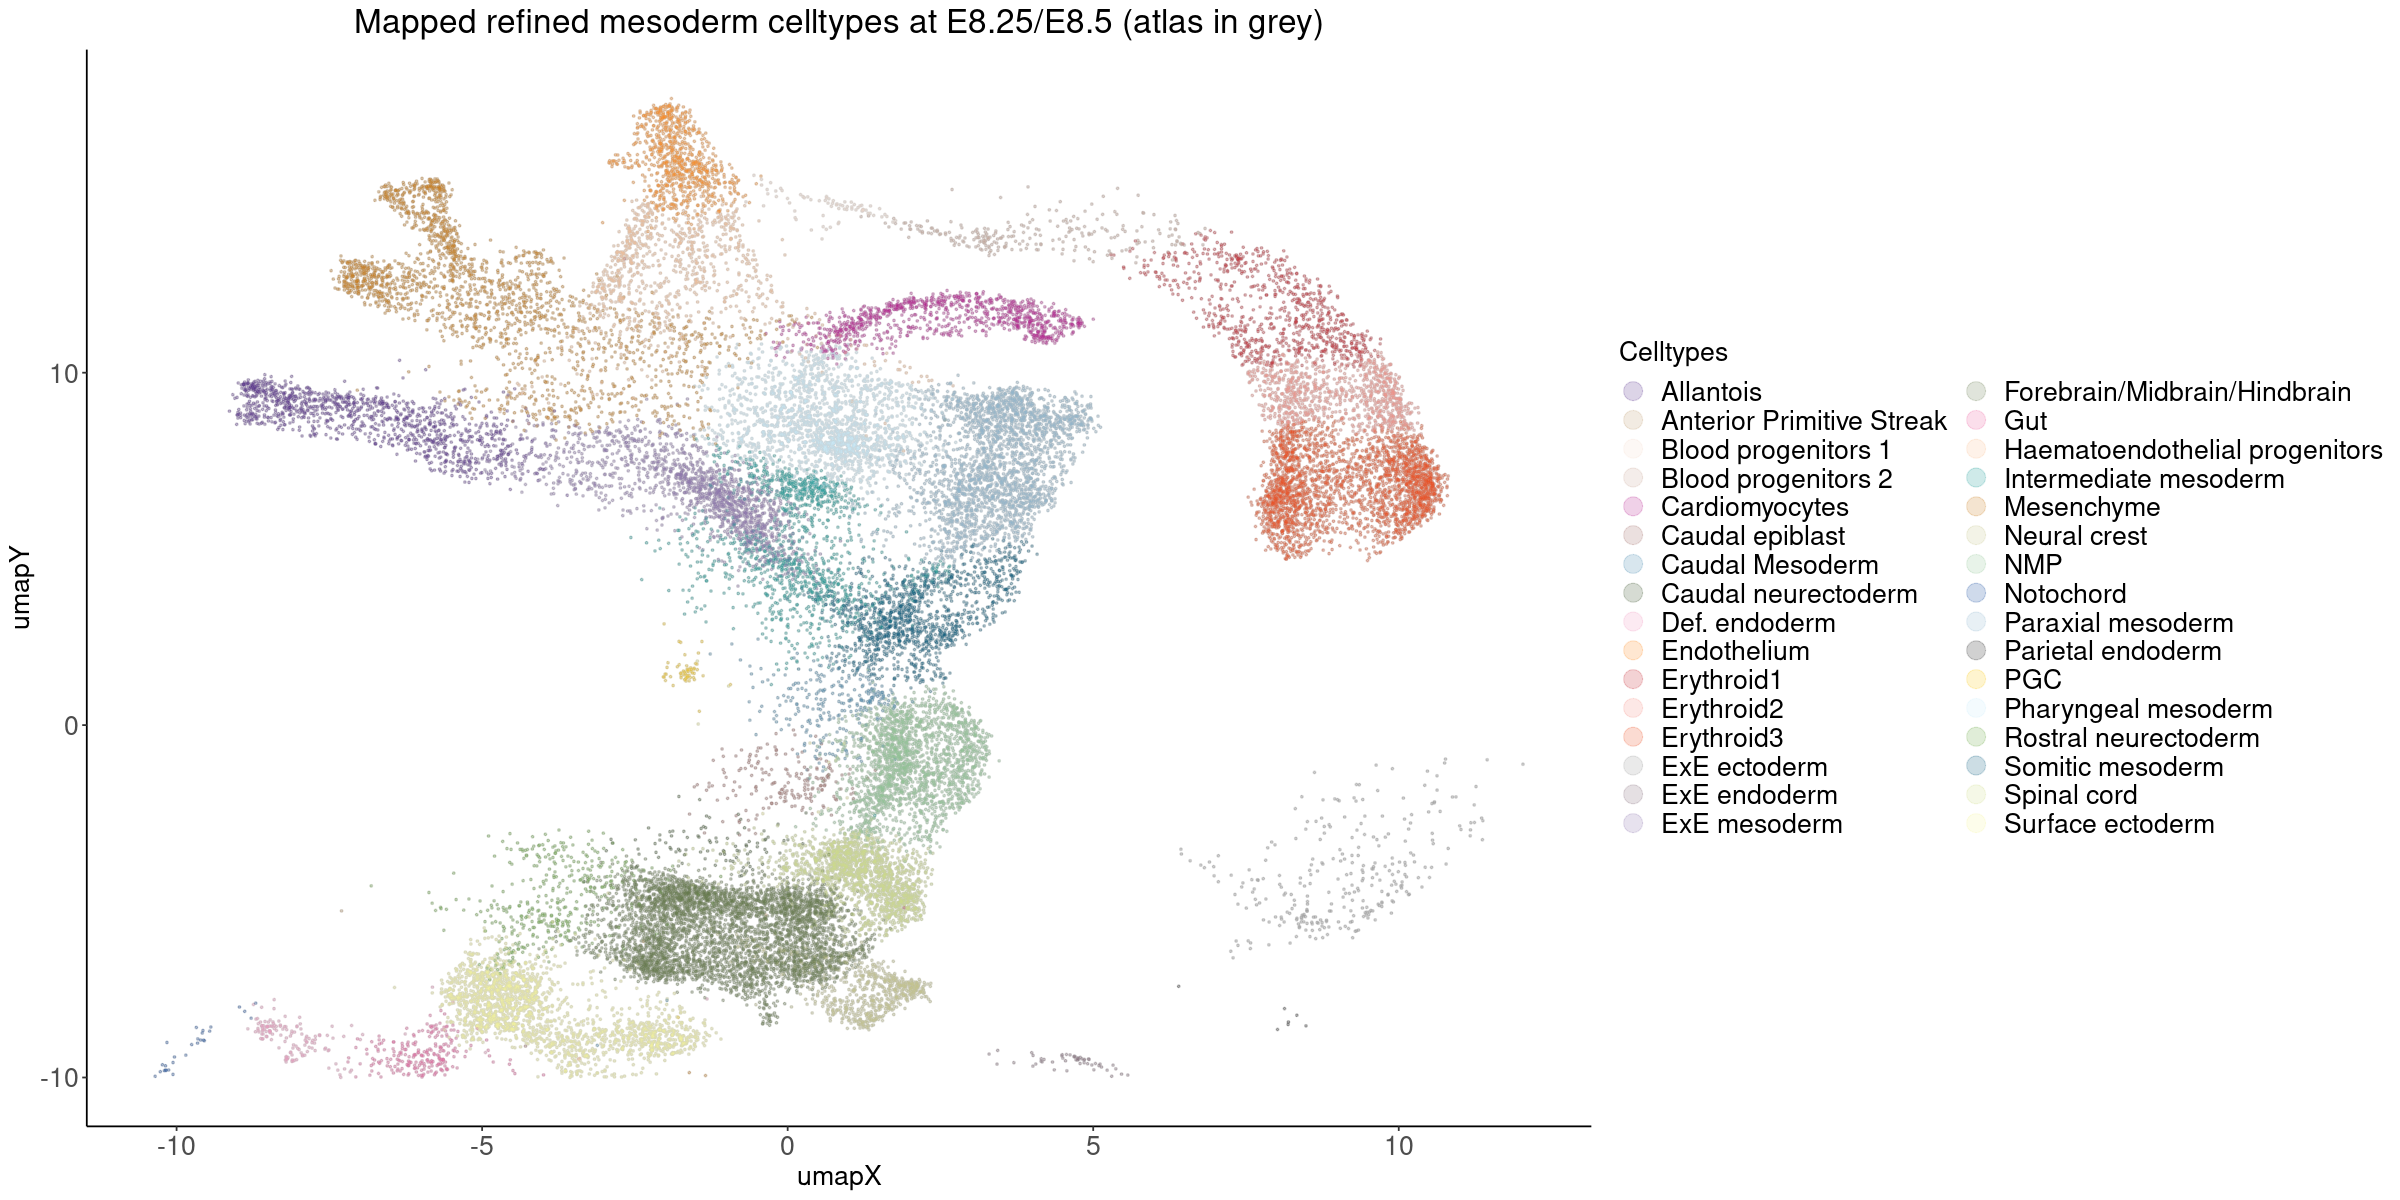

In [53]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umapY >= -10)

p1 <- ggplot(big_meta_85, aes(umapX, umapY, color= celltype.mapped)) +
    geom_point(alpha=0.5, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

plot_grid(p1)

Warning message:
“Removed 30740 rows containing missing values (geom_point).”


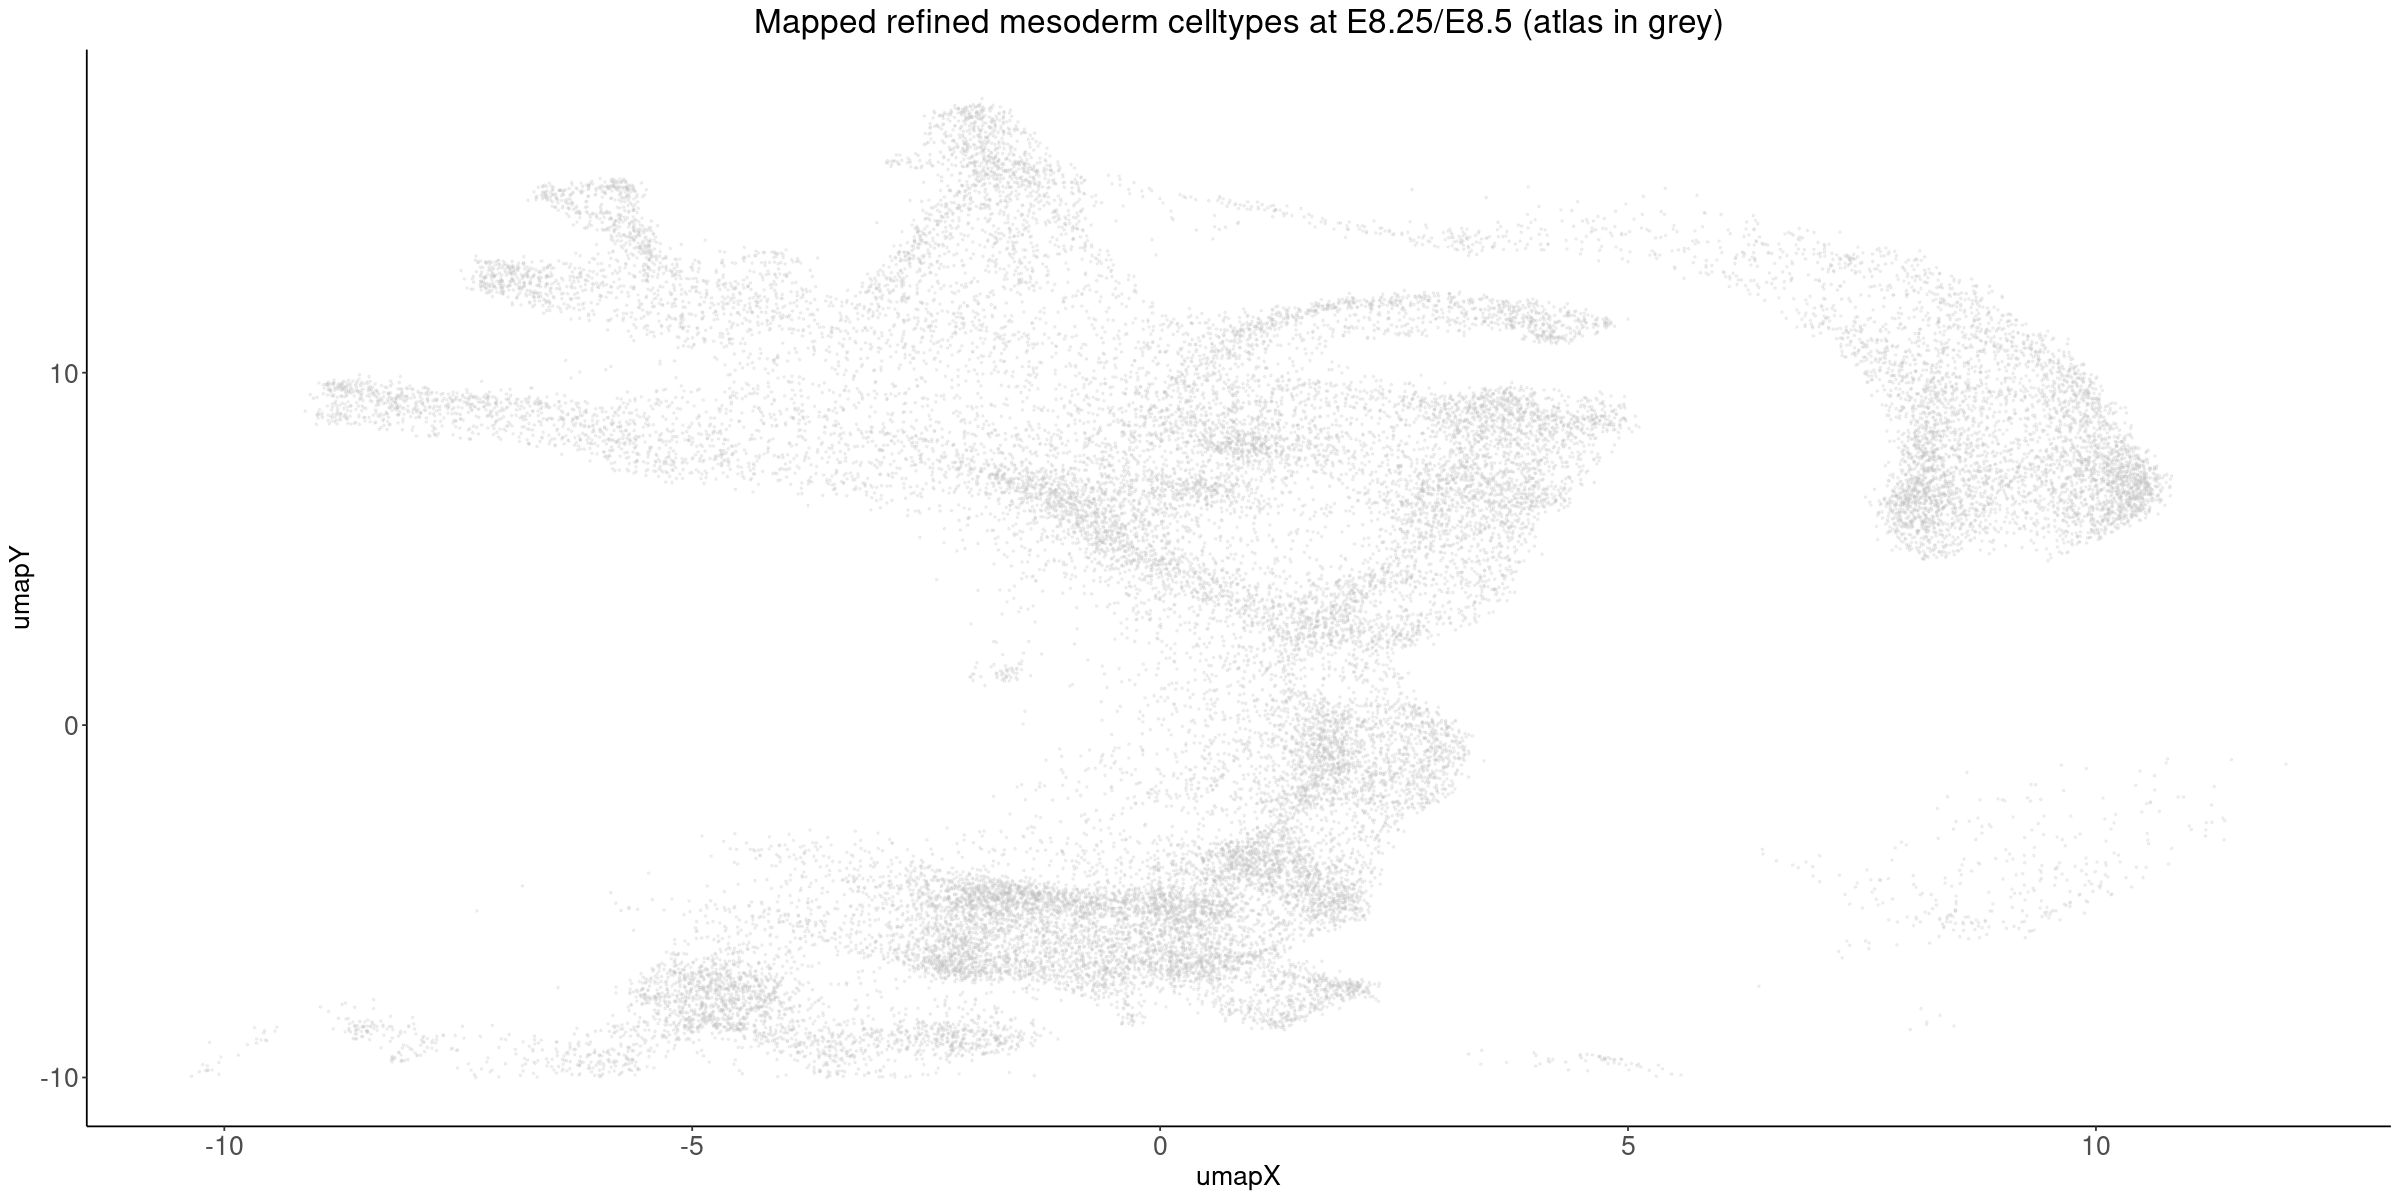

In [56]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umapY >= -10)

#p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= meso.mapped)) +
    #geom_point(alpha=0.5, size = 0.4, color='grey') +
    #geom_point(data=big_meta_85,aes(color=meso_subcluster),alpha=0.2, size = 0.4) +
    #theme_classic() +
    #scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    #ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +
    #theme(legend.position = "none") +
    #theme(plot.title = element_text(hjust = 0.5)) +
    #theme(plot.title = element_text(size=20)) +
    #theme(legend.text=element_text(size=16)) + 
    #theme(legend.title=element_text(size=16)) +
    #theme(axis.text = element_text(size = 16)) +
    #theme(axis.title = element_text(size = 16))

#meso.mapped as a function of meso_subcluster
p2 <- ggplot(big_meta_85, aes(umapX, umapY, color=meso_subcluster)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = meso_colours, labels = meso_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +     
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

plot_grid(
  #p1, 
  p2,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [ ]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_celltype_mapping+meso.png"), height=750, width=1250)
    grid.arrange(p1, p2)
dev.off()

Warning message:
“Removed 30740 rows containing missing values (geom_point).”


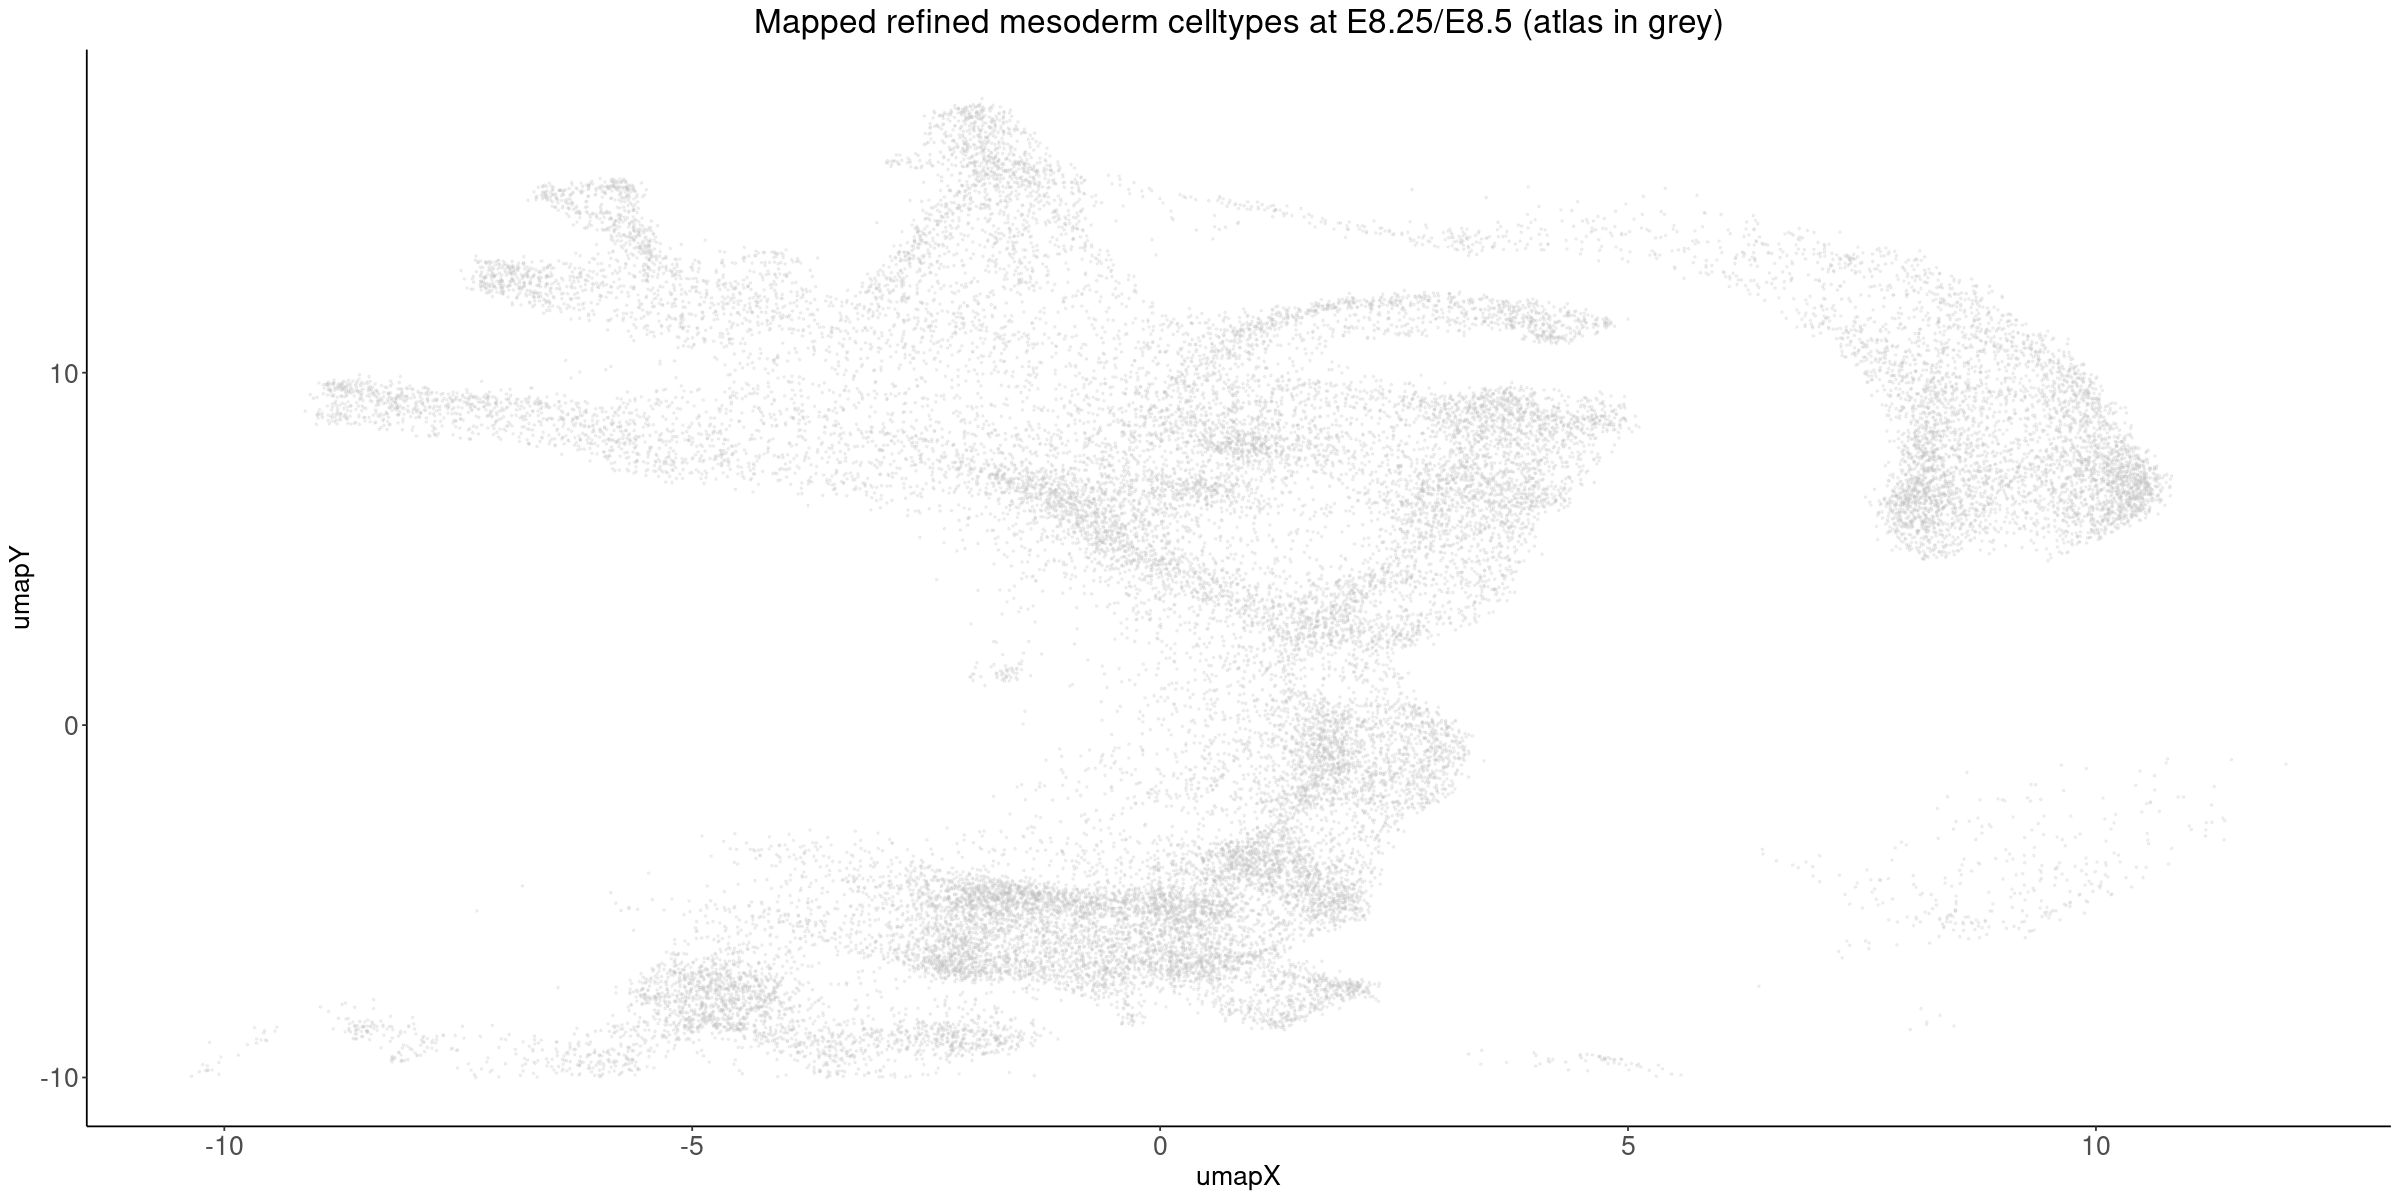

In [55]:
p2 <- ggplot(big_meta_85, aes(umapX, umapY, color=celltype)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=meso.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = meso_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +     
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))



plot_grid(
  p2,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [ ]:
unique(big_meta$celltype.mapped)

In [ ]:
unique(big_meta$meso_subcluster)

# want to see what initially mapped celltypes were converted to new celltypes

In [59]:
# want to see what initially mapped celltypes were converted to new celltypes
celltype_origin = List()
big_meta["celltype_origin"] <- NA

In [60]:
big_meta$celltype_origin = as.character(big_meta$celltype[match(big_meta$cell, meta_meso$cell)]) #atlas cells

In [61]:
length(unique(big_meta$celltype))

[1] 37

In [62]:
length(unique(big_meta$celltype_origin))

[1] 29

In [63]:
df <- unclass(table(big_meta$celltype_origin))
df

Allantois            Blood progenitors 1 
                             1                             13 
           Blood progenitors 2                Caudal epiblast 
                            32                             32 
               Caudal Mesoderm            Caudal neurectoderm 
                             4                              4 
                 Def. endoderm                       Epiblast 
                            15                            458 
                    Erythroid1                   ExE ectoderm 
                             1                            307 
                  ExE endoderm                   ExE mesoderm 
                           247                             16 
                           Gut Haematoendothelial progenitors 
                            15                             20 
         Intermediate mesoderm                     Mesenchyme 
                            24                             78 
                Mixed mesoderm               Nascent mesoderm 
                            63                             41 
                     Notochord              Paraxial mesoderm 
                             6                              9 
             Parietal endoderm                            PGC 
                             7                              7 
           Pharyngeal mesoderm               Primitive Streak 
                            14                            109 
          Rostral neurectoderm               Somitic mesoderm 
                            95                              4 
              Surface ectoderm              Visceral endoderm 
                            23                             57

In [64]:
df <- as.data.frame(df) 

In [65]:
summary(df)

       df        
 Min.   :  1.00  
 1st Qu.:  7.00  
 Median : 18.00  
 Mean   : 60.79  
 3rd Qu.: 58.50  
 Max.   :458.00  

In [66]:
rownames(df)
df

[1] "Allantois"                      "Blood progenitors 1"           
 [3] "Blood progenitors 2"            "Caudal epiblast"               
 [5] "Caudal Mesoderm"                "Caudal neurectoderm"           
 [7] "Def. endoderm"                  "Epiblast"                      
 [9] "Erythroid1"                     "ExE ectoderm"                  
[11] "ExE endoderm"                   "ExE mesoderm"                  
[13] "Gut"                            "Haematoendothelial progenitors"
[15] "Intermediate mesoderm"          "Mesenchyme"                    
[17] "Mixed mesoderm"                 "Nascent mesoderm"              
[19] "Notochord"                      "Paraxial mesoderm"             
[21] "Parietal endoderm"              "PGC"                           
[23] "Pharyngeal mesoderm"            "Primitive Streak"              
[25] "Rostral neurectoderm"           "Somitic mesoderm"              
[27] "Surface ectoderm"               "Visceral endoderm"

,df
,<int>
Allantois,1
Blood progenitors 1,13
Blood progenitors 2,32
Caudal epiblast,32
Caudal Mesoderm,4
Caudal neurectoderm,4
Def. endoderm,15
Epiblast,458
Erythroid1,1


In [67]:
df$count <- df$df
#df$celltype <- rownames(df)
sum(df$count)
percent <- list()
df['percent'] <- NA
df

[1] 1702

,df,count,percent
,<int>,<int>,<lgl>
Allantois,1,1,NA
Blood progenitors 1,13,13,NA
Blood progenitors 2,32,32,NA
Caudal epiblast,32,32,NA
Caudal Mesoderm,4,4,NA
Caudal neurectoderm,4,4,NA
Def. endoderm,15,15,NA
Epiblast,458,458,NA
Erythroid1,1,1,NA


In [68]:
df <- df %>% tibble::rownames_to_column() %>% mutate(df, percent = count / sum(count) * 100)

df

rowname,df,count,percent
<chr>,<int>,<int>,<dbl>
Allantois,1,1,0.05875441
Blood progenitors 1,13,13,0.76380729
Blood progenitors 2,32,32,1.88014101
Caudal epiblast,32,32,1.88014101
Caudal Mesoderm,4,4,0.23501763
Caudal neurectoderm,4,4,0.23501763
Def. endoderm,15,15,0.88131610
Epiblast,458,458,26.90951821
Erythroid1,1,1,0.05875441


In [69]:
df

rowname,df,count,percent
<chr>,<int>,<int>,<dbl>
Allantois,1,1,0.05875441
Blood progenitors 1,13,13,0.76380729
Blood progenitors 2,32,32,1.88014101
Caudal epiblast,32,32,1.88014101
Caudal Mesoderm,4,4,0.23501763
Caudal neurectoderm,4,4,0.23501763
Def. endoderm,15,15,0.88131610
Epiblast,458,458,26.90951821
Erythroid1,1,1,0.05875441


In [70]:
df2 <- df[order(-df$count),]
df2
df3 <- df2[1:21,]
df3
sum(df3$percent) #95.2996474735605
sum(df3$percent[1:10]) #64.9236192714454
sum(df3$percent[1:6]) #45.6521739130435

,rowname,df,count,percent
,<chr>,<int>,<int>,<dbl>
8,Epiblast,458,458,26.90951821
10,ExE ectoderm,307,307,18.03760282
11,ExE endoderm,247,247,14.51233843
24,Primitive Streak,109,109,6.40423032
25,Rostral neurectoderm,95,95,5.58166863
16,Mesenchyme,78,78,4.58284371
17,Mixed mesoderm,63,63,3.70152761
28,Visceral endoderm,57,57,3.34900118
18,Nascent mesoderm,41,41,2.40893067


,rowname,df,count,percent
,<chr>,<int>,<int>,<dbl>
8,Epiblast,458,458,26.9095182
10,ExE ectoderm,307,307,18.0376028
11,ExE endoderm,247,247,14.5123384
24,Primitive Streak,109,109,6.4042303
25,Rostral neurectoderm,95,95,5.5816686
16,Mesenchyme,78,78,4.5828437
17,Mixed mesoderm,63,63,3.7015276
28,Visceral endoderm,57,57,3.3490012
18,Nascent mesoderm,41,41,2.4089307


[1] 98.41363

[1] 87.3678

[1] 76.0282

In [71]:
# save mapped celltypes
write.csv(df2, paste0(out_folder, 'wt_original_celltype_of_remapped_cells-meso.csv')) 

In [73]:
df5 <- unclass(table(big_meta$meso.mapped))
sum(df5)

[1] 235

#convert celltype.mapped to meso.mapped too for non-newly mapped cells as for some celltypes, up to 10% to new meso subcluster which might skew DEG results
for (cell in big_meta$cell) {
    if (is.na(big_meta$meso.mapped)) {
        big_meta$meso.mapped = as.character(big_meta$celltype.mapped)
    } }

In [152]:
### save big meta with mapping
#write.table(big_meta, file = paste0(out_folder,"big_meta_mapping+meso3.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

# more visualizations

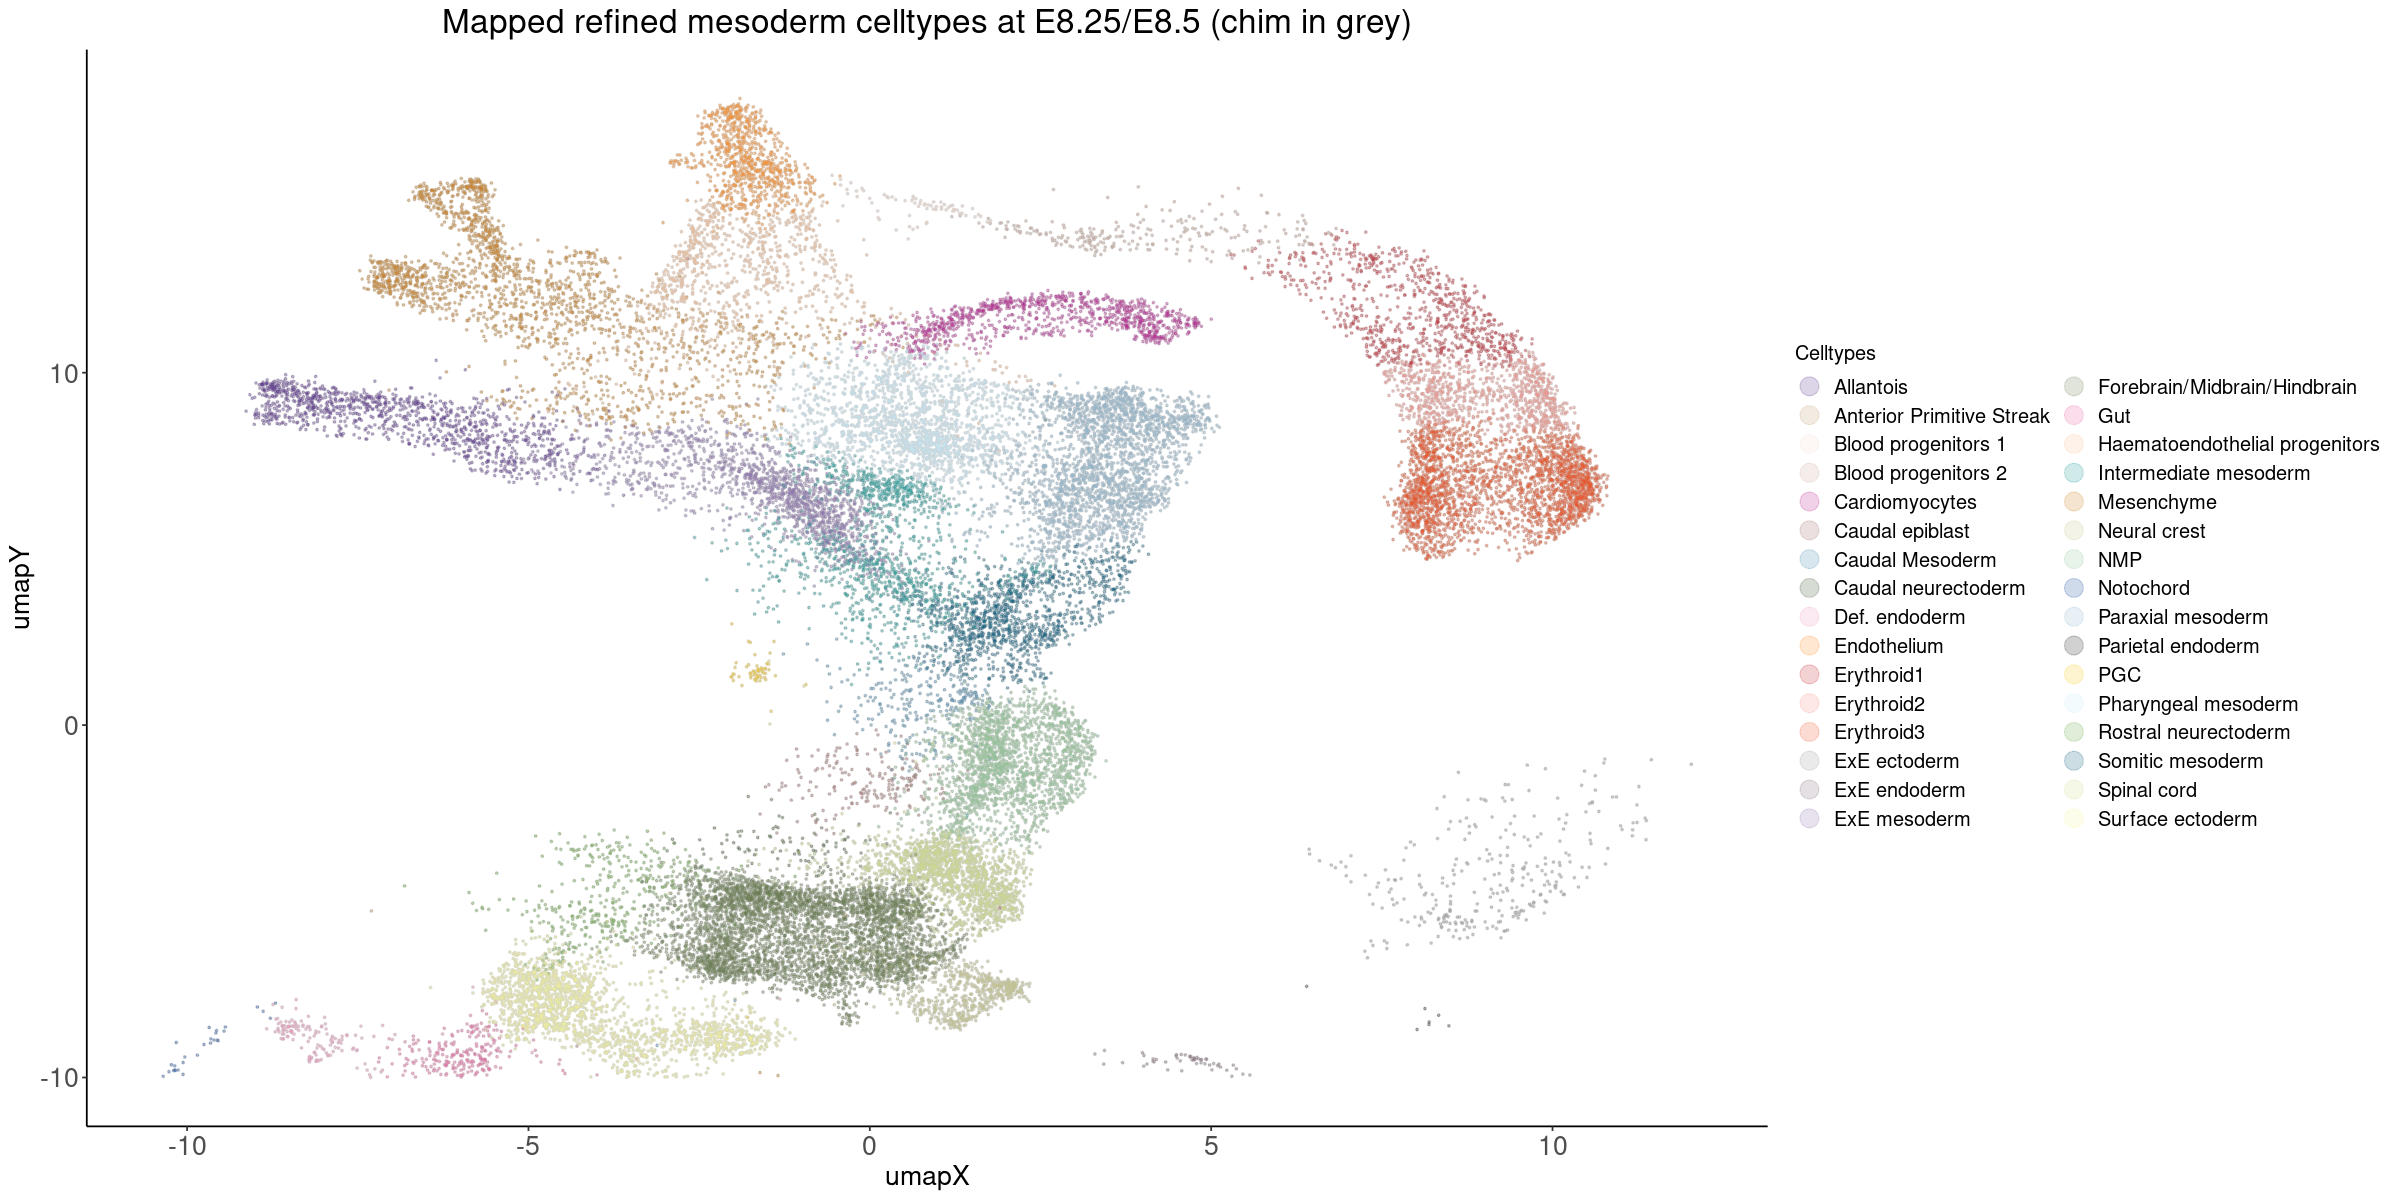

In [58]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umapY >= -10)

#plot of originally mapped cells now meso.mapped
p1 <- ggplot(big_meta_85, aes(umapX, umapY, color= meso_subcluster)) + 
    geom_point(alpha=0.5, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (chim in grey)') +
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))


plot_grid(
  p1,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [92]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_celltype_mapping_meso_original_celltypes.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

Warning message:
“Removed 67887 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 11389 rows containing missing values (geom_point).”


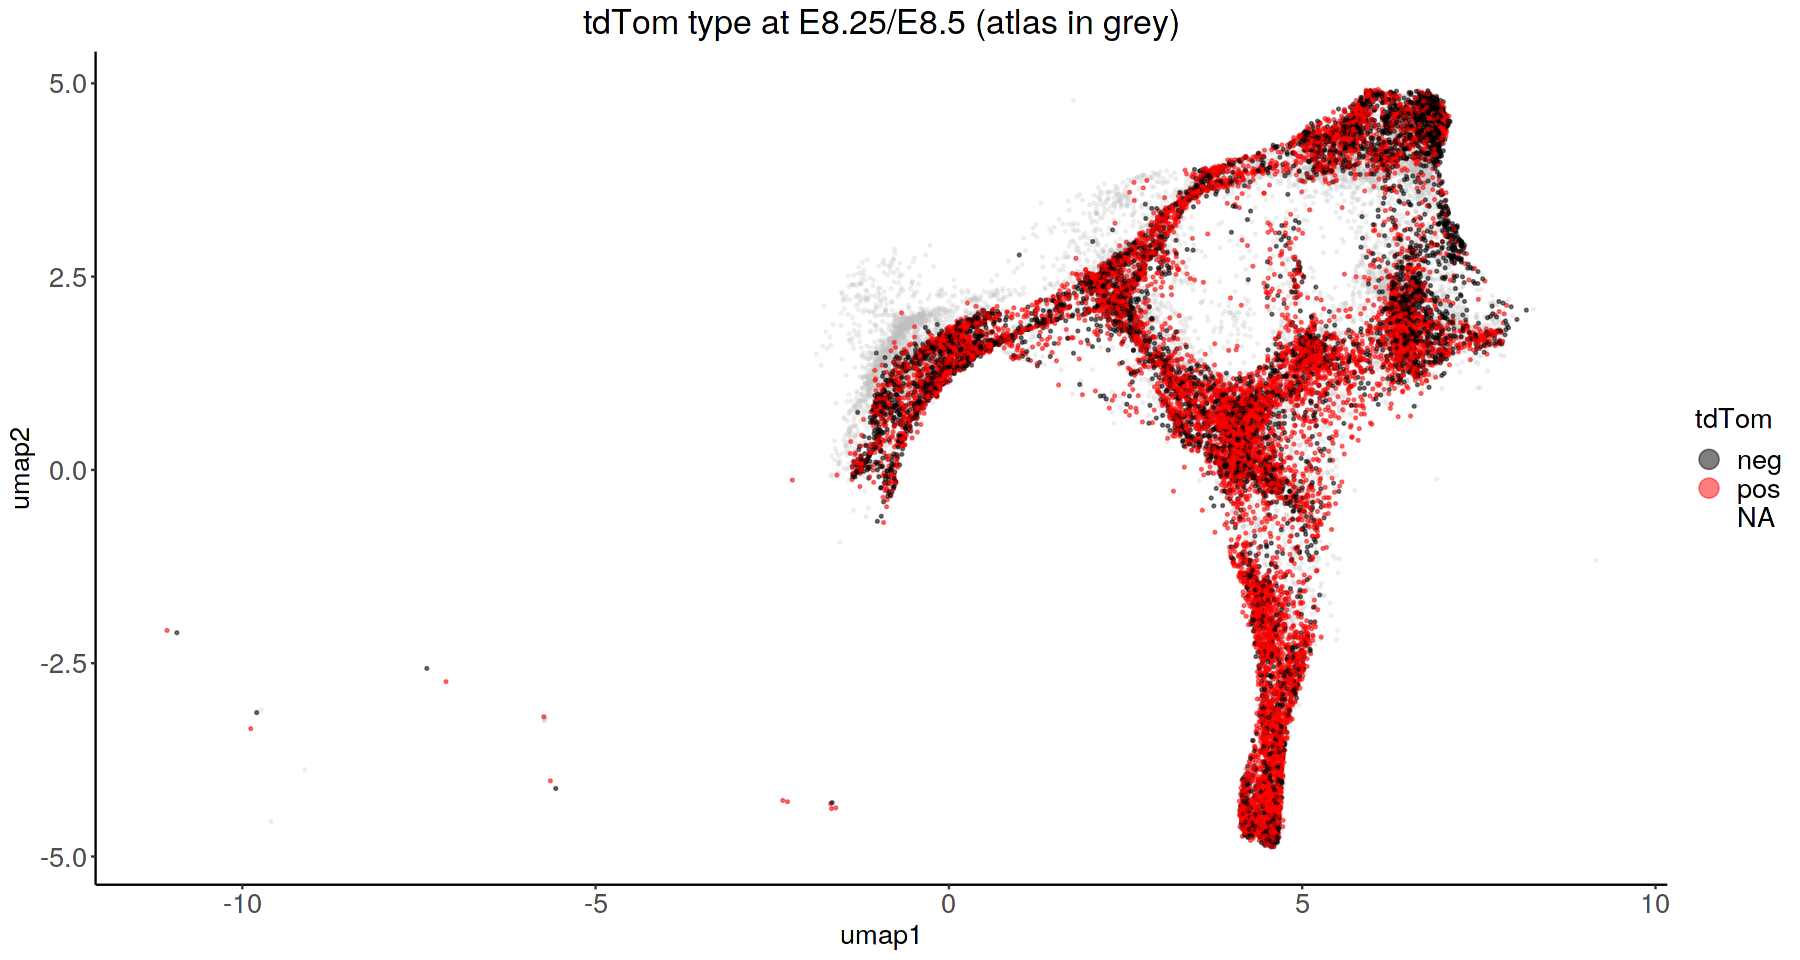

In [93]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)

meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")
meso_plot <- big_meta_85 %>% filter(celltype %in% meso | celltype.mapped %in% meso | meso.mapped %in% meso )


p2 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=tdTom),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) + 
    ggtitle('tdTom type at E8.25/E8.5 (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p2)

In [94]:
png(paste0(plot_folder, "umap_meso_mapping_dtTOM.png"), height=750, width=900)
    grid.arrange(p2)
dev.off()

Warning message:
“Removed 11389 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 26098 rows containing missing values (geom_point).”


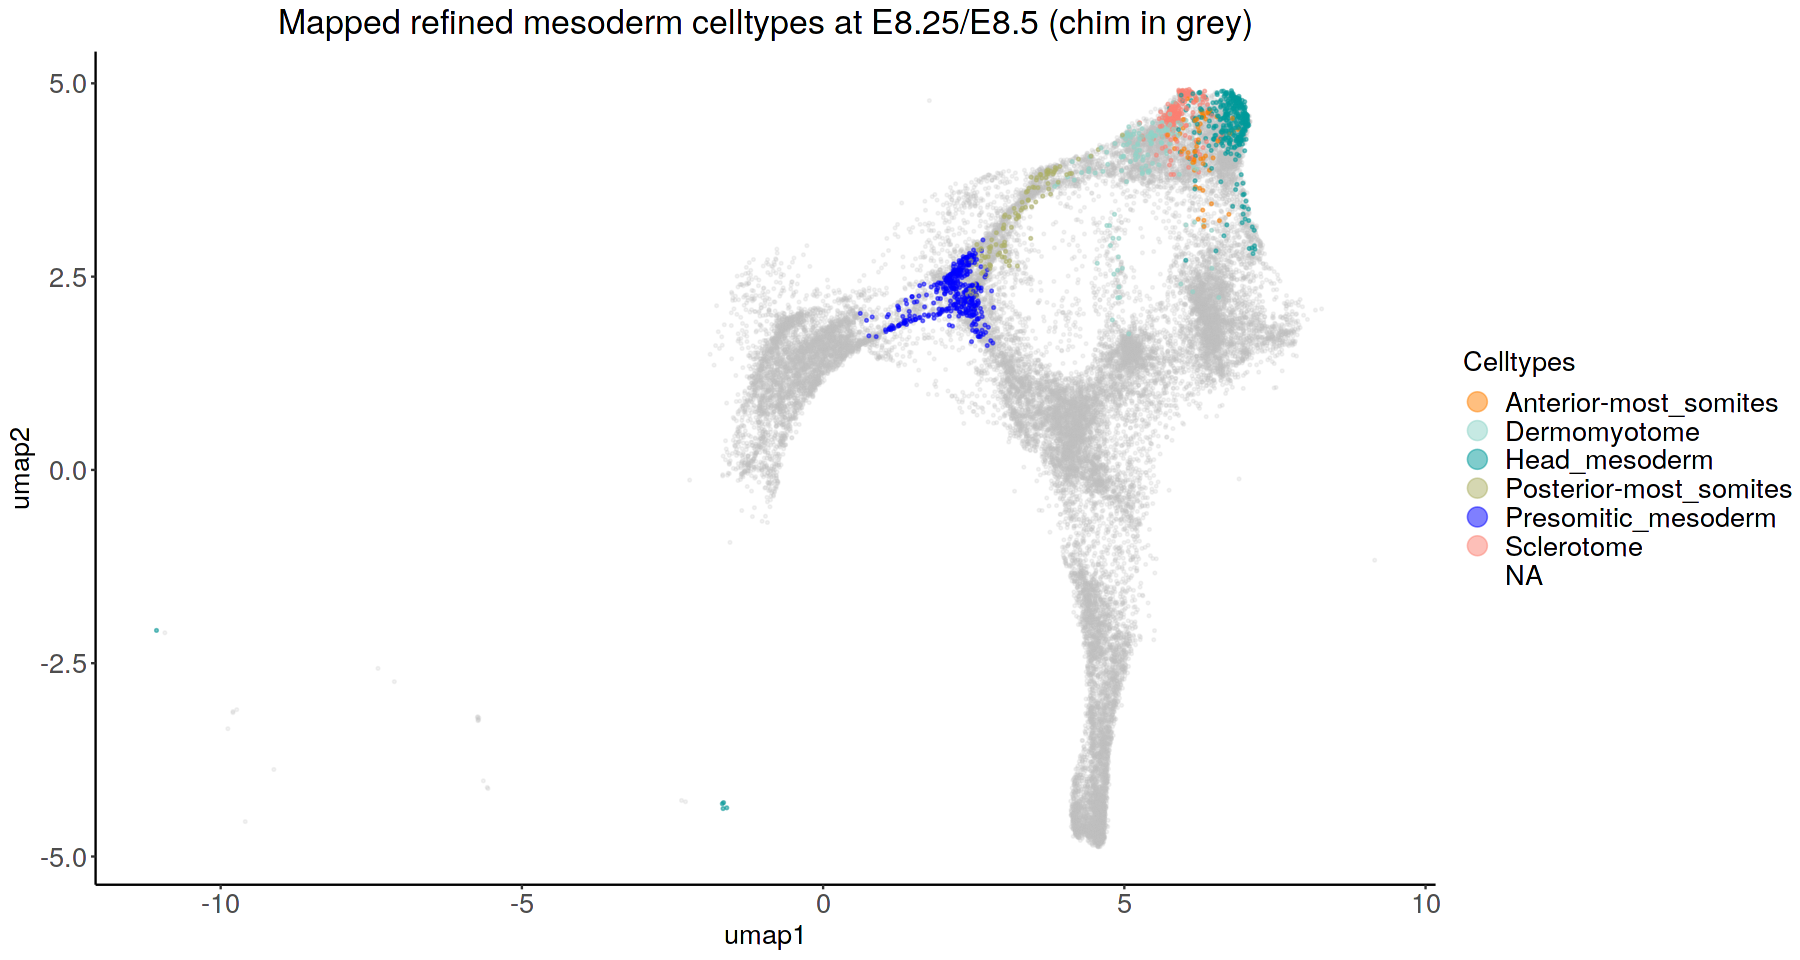

In [95]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)

meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")


meso_plot <- big_meta_85 %>% filter(celltype %in% meso | celltype.mapped %in% meso | meso.mapped %in% meso )
p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=meso.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (chim in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p1)

In [96]:
png(paste0(plot_folder, "umap_meso_mapping_chim_meso-region.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

Warning message:
“Removed 26098 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 11050 rows containing missing values (geom_point).”


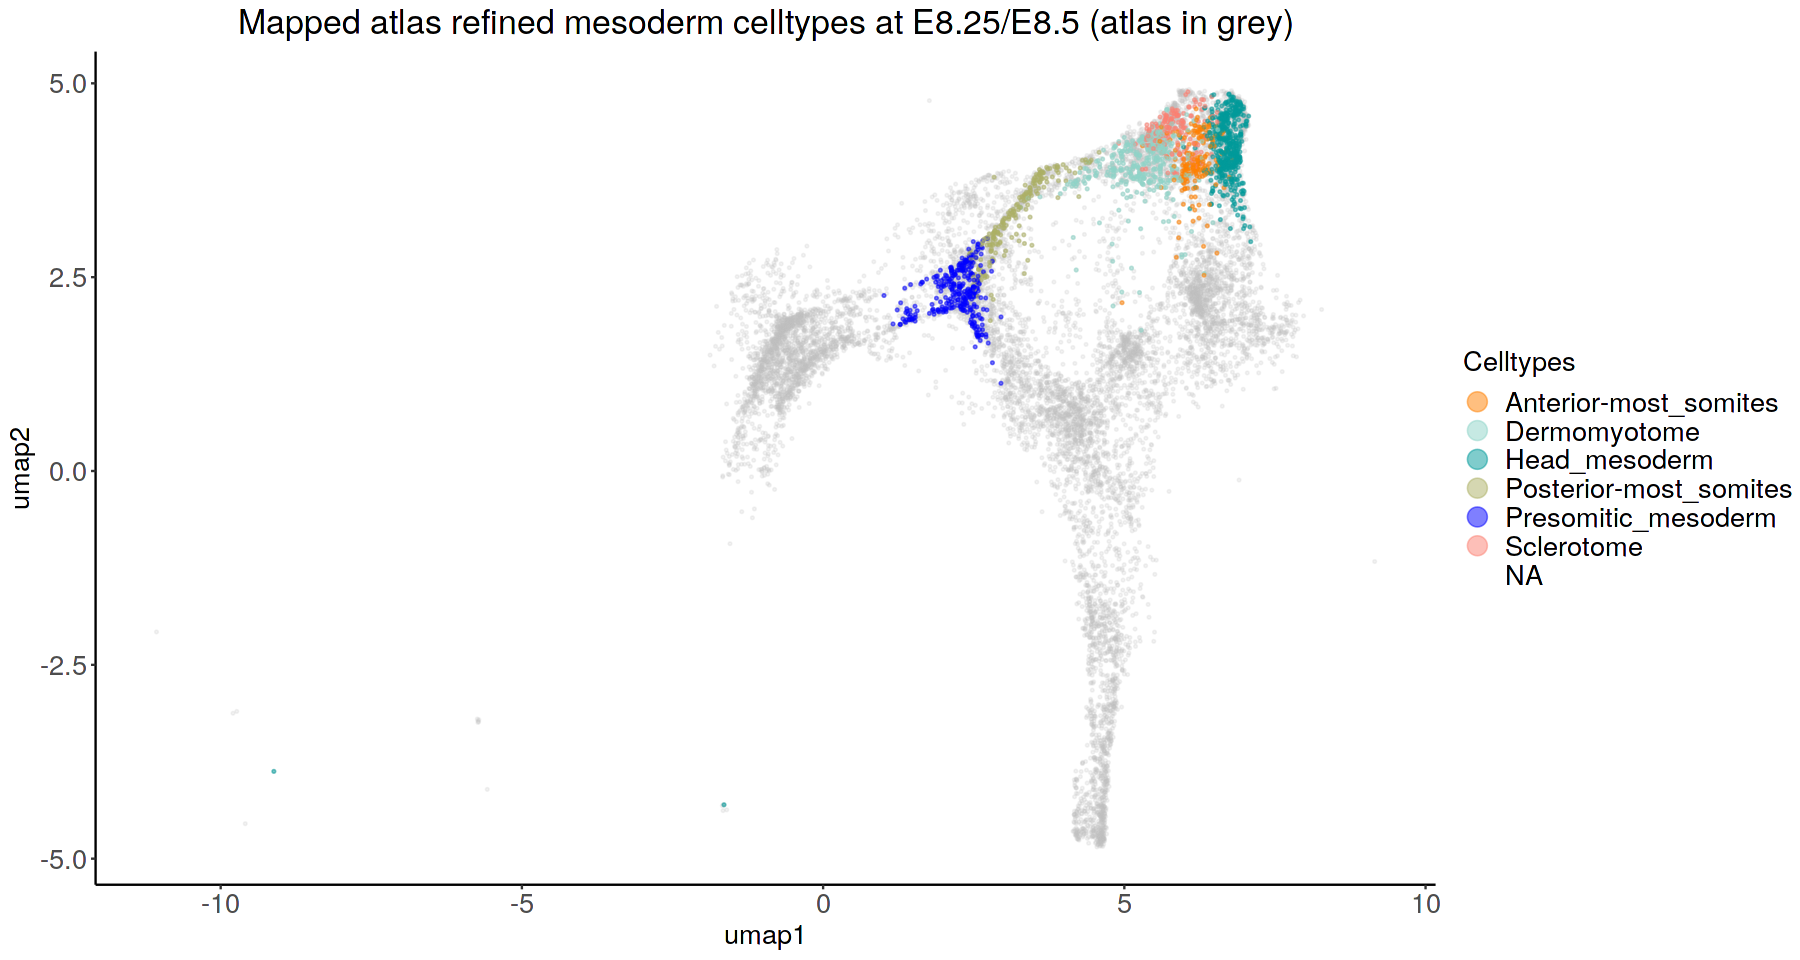

In [97]:
meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")


meso_plot <- big_meta_85 %>% filter(celltype %in% meso | meso.mapped %in% meso | meso_subcluster %in% meso )


p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=meso_subcluster),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped atlas refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p1)

In [98]:
png(paste0(plot_folder, "umap_meso_mapping_atlas.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

Warning message:
“Removed 11050 rows containing missing values (geom_point).”


png 
  2

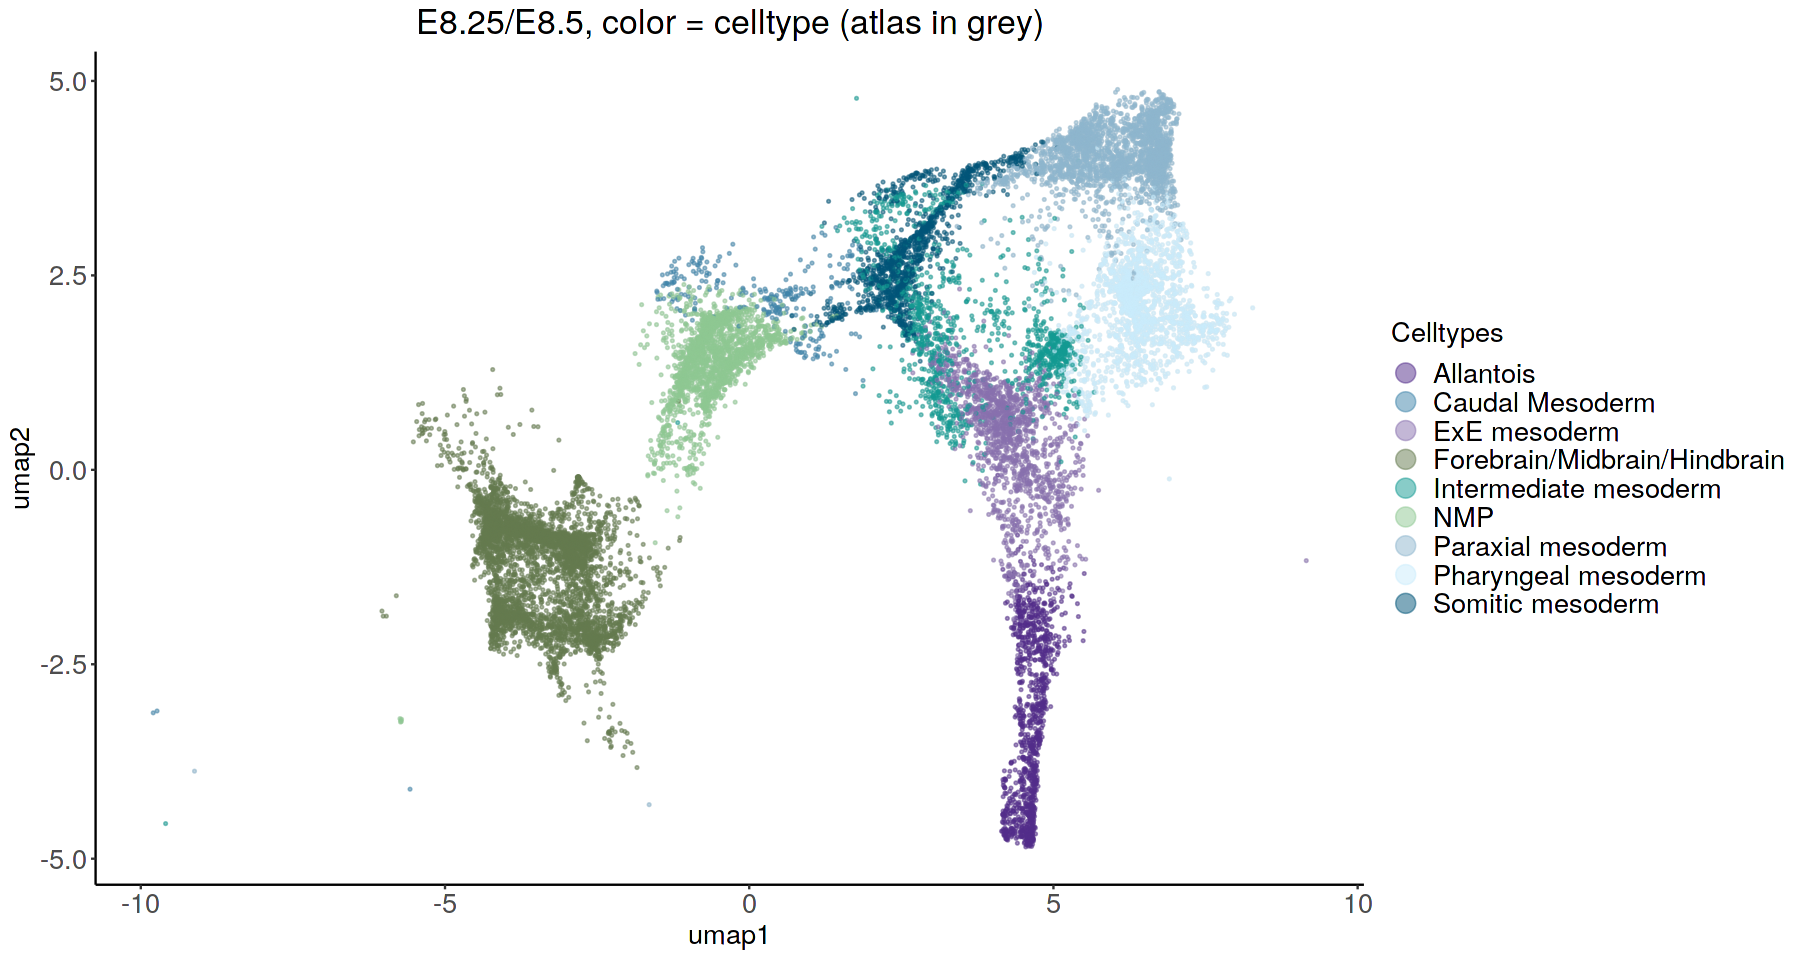

In [99]:
meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP",
                     "Forebrain/Midbrain/Hindbrain")


meso_plot <- big_meta_85 %>% filter(celltype %in% meso | celltype_origin %in% meso )


p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=celltype),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p1)

In [100]:
png(paste0(plot_folder, "umap_mapping_atlas.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

png 
  2

In [166]:
colnames(big_meta)

[1] "cell"                "sample"              "stage"              
 [4] "barcode"             "sequencing.batch"    "stripped"           
 [7] "doublet"             "theiler"             "doub.density"       
[10] "cluster"             "cluster.sub"         "cluster.stage"      
[13] "cluster.theiler"     "celltype"            "colour"             
[16] "umapX"               "umapY"               "haem_gephiX"        
[19] "haem_gephiY"         "haem_subclust"       "endo_gephiX"        
[22] "endo_gephiY"         "endo_trajectoryName" "endo_trajectoryDPT" 
[25] "endo_gutX"           "endo_gutY"           "endo_gutDPT"        
[28] "endo_gutCluster"     "weight"              "stage.mapped"       
[31] "celltype.mapped"     "closest.cell"        "tdTom"              
[34] "meso.mapped"         "meso_subcluster"     "umap1"              
[37] "umap2"               "celltype_origin"     "origin"

In [165]:
df <- unclass(table(big_meta$celltype.mapped))
df

Allantois      Anterior Primitive Streak 
                          2881                              1 
           Blood progenitors 1            Blood progenitors 2 
                           127                            460 
                Cardiomyocytes                Caudal epiblast 
                          1225                              7 
               Caudal Mesoderm            Caudal neurectoderm 
                           153                              1 
                 Def. endoderm                    Endothelium 
                           444                             22 
                    Erythroid1                     Erythroid2 
                          1141                           2495 
                    Erythroid3                   ExE ectoderm 
                          1518                            167 
                  ExE endoderm                   ExE mesoderm 
                           111                           2977 
  Forebrain/Midbrain/Hindbrain                            Gut 
                          5337                           1102 
Haematoendothelial progenitors          Intermediate mesoderm 
                            19                           1625 
                    Mesenchyme                 Mixed mesoderm 
                           640                              1 
                  Neural crest                            NMP 
                          1407                           2049 
                     Notochord              Paraxial mesoderm 
                            75                           2606 
             Parietal endoderm                            PGC 
                             1                             91 
           Pharyngeal mesoderm           Rostral neurectoderm 
                          2155                             27 
              Somitic mesoderm                    Spinal cord 
                          1621                           1962 
              Surface ectoderm              Visceral endoderm 
                          2713                             47